## FIFA Dataset Description

This dataset contains detailed information about football players, including their attributes, contract data, and positions. Below is a breakdown of the main features:

### Feature Table with Descriptions

**Original Features**

| Column Name          | Description |
|:---------------------|:------------|
| LongName             | Player’s full name |
| Nationality          | Player’s nationality |
| Positions            | Player’s positions |
| Name                 | Player’s name |
| Age                  | Player’s age |
| Overall Rating       | Player’s overall rating |
| Potential            | Player’s potential rating |
| ID                   | Player’s unique identifier |
| Weight               | Player’s weight |
| foot                 | Player’s dominant foot |
| Best Overall         | Player’s best overall rating |
| Best Position        | Player’s best position |
| Growth               | Player’s growth potential |
| Value                | Player’s market value |
| Wage                 | Player’s wage |
| Release Clause       | Player’s release clause amount |
| ... (and so on)      | ... (descriptions for other features) |

**Encoded Positions**

| Column Name | Description |
|:------------|:------------|
| CM          | Central Midfielder |
| ST          | Striker |
| RB          | Right Back |
| GK          | Goalkeeper |
| CB          | Center Back |
| RWB         | Right Wing Back |
| LB          | Left Back |
| RM          | Right Midfielder |
| LM          | Left Midfielder |
| LW          | Left Winger |
| CDM         | Defensive Midfielder |
| CAM         | Attacking Midfielder |
| LWB         | Left Wing Back |
| CF          | Center Forward |
| RW          | Right Winger |

**Additional Features**

| Column Name | Description |
|:------------|:------------|
| Team        | Player’s team |
| Start Year  | Player’s contract start year |
| End Year    | Player’s contract end year |
| Height      | Player’s height |
| Date        | Date the player joined the team |
| Year        | Player’s contract year |
| Month       | Player’s contract month |
| Day         | Player’s contract day |
| Hits        | Unknown attribute (requires further clarification) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading and cleaning both datasets

In [ ]:
df_soccer = pd.read_excel('FIFA_Complete_DATASET.xlsx', sheet_name='Fifa')

## Cleaning Fifa Dataset

In [9]:
df_soccer.head()

,LongName,Nationality,Positions,Name,Age,Overall Rating,Potential,ID,Weight,foot,...,Physicality,Hits,Team,Start Year,End Year,Height,Date,Year,Month,Day
0,Lionel Messi,Argentina,RW ST CF,L. Messi,33,93,93,158023,72.121128,Left,...,65,372,FC Barcelona,2004.0,2021.0,159.40,2004-07-01,2004,7,1
1,C. Ronaldo dos Santos Aveiro,Portugal,ST LW,Cristiano Ronaldo,35,92,92,20801,83.007336,Right,...,77,344,Juventus,2018.0,2022.0,184.88,2018-07-10,2018,7,10
2,Jan Oblak,Slovenia,GK,J. Oblak,27,91,93,200389,87.089664,Right,...,90,86,Atlético Madrid,2014.0,2023.0,184.88,2014-07-16,2014,7,16
3,Kevin De Bruyne,Belgium,CAM CM,K. De Bruyne,29,91,91,192985,69.853168,Right,...,78,163,Manchester City,2015.0,2023.0,163.40,2015-08-30,2015,8,30
4,Neymar da Silva Santos Jr.,Brazil,LW CAM,Neymar Jr,28,91,91,190871,68.038800,Right,...,59,273,Germain,2017.0,2022.0,161.40,2017-08-03,2017,8,3


In [10]:
df_soccer.shape

(18852, 79)

In [11]:
df_soccer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18852 entries, 0 to 18851
Data columns (total 79 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   LongName                  18852 non-null  object        
 1   Nationality               18852 non-null  object        
 2   Positions                 18852 non-null  object        
 3   Name                      18852 non-null  object        
 4   Age                       18852 non-null  int64         
 5   Overall Rating            18852 non-null  int64         
 6   Potential                 18852 non-null  int64         
 7   ID                        18852 non-null  int64         
 8   Weight                    18852 non-null  float64       
 9   foot                      18852 non-null  object        
 10  Best Overall              18852 non-null  int64         
 11  Best Position             18852 non-null  object        
 12  Growth            

In [12]:
features_for_clustering = [
    'Finishing',
    'Short Passing',
    'Standing Tackle',
    'Sprint Speed',
    'Strength',
    'Dribbling',
    'Crossing',
    'Interceptions',
    'Vision',
    'GK Reflexes'
]

In [13]:
df_soccer_clustering = df_soccer[features_for_clustering]

In [16]:
df_soccer_clustering.head()

,Finishing,Short Passing,Standing Tackle,Sprint Speed,Strength,Dribbling,Crossing,Interceptions,Vision,GK Reflexes
0,95,91,35,80,69,96,85,40,95,8
1,95,82,32,91,78,88,84,29,82,11
2,11,43,12,60,78,12,13,19,65,90
3,82,94,65,76,74,88,94,66,94,13
4,87,87,30,89,50,95,85,36,90,11


### Univariate Analysis

In [47]:
import math

def plot_feature_distributions(df: pd.DataFrame, features:list, flag:str='hist'):
    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        if flag == 'hist':
            sns.histplot(df[feature], kde=True, bins=30, ax=axes[i])
        else:
            sns.boxplot(x=df[feature], ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [48]:
def remove_outliers(df: pd.DataFrame, columns: list = None, threshold: float = 1.5) -> pd.DataFrame:
    
    mask = pd.Series(True, index=df.index)

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        mask &= df[col].between(lower, upper)

    return df[mask].reset_index(drop=True)

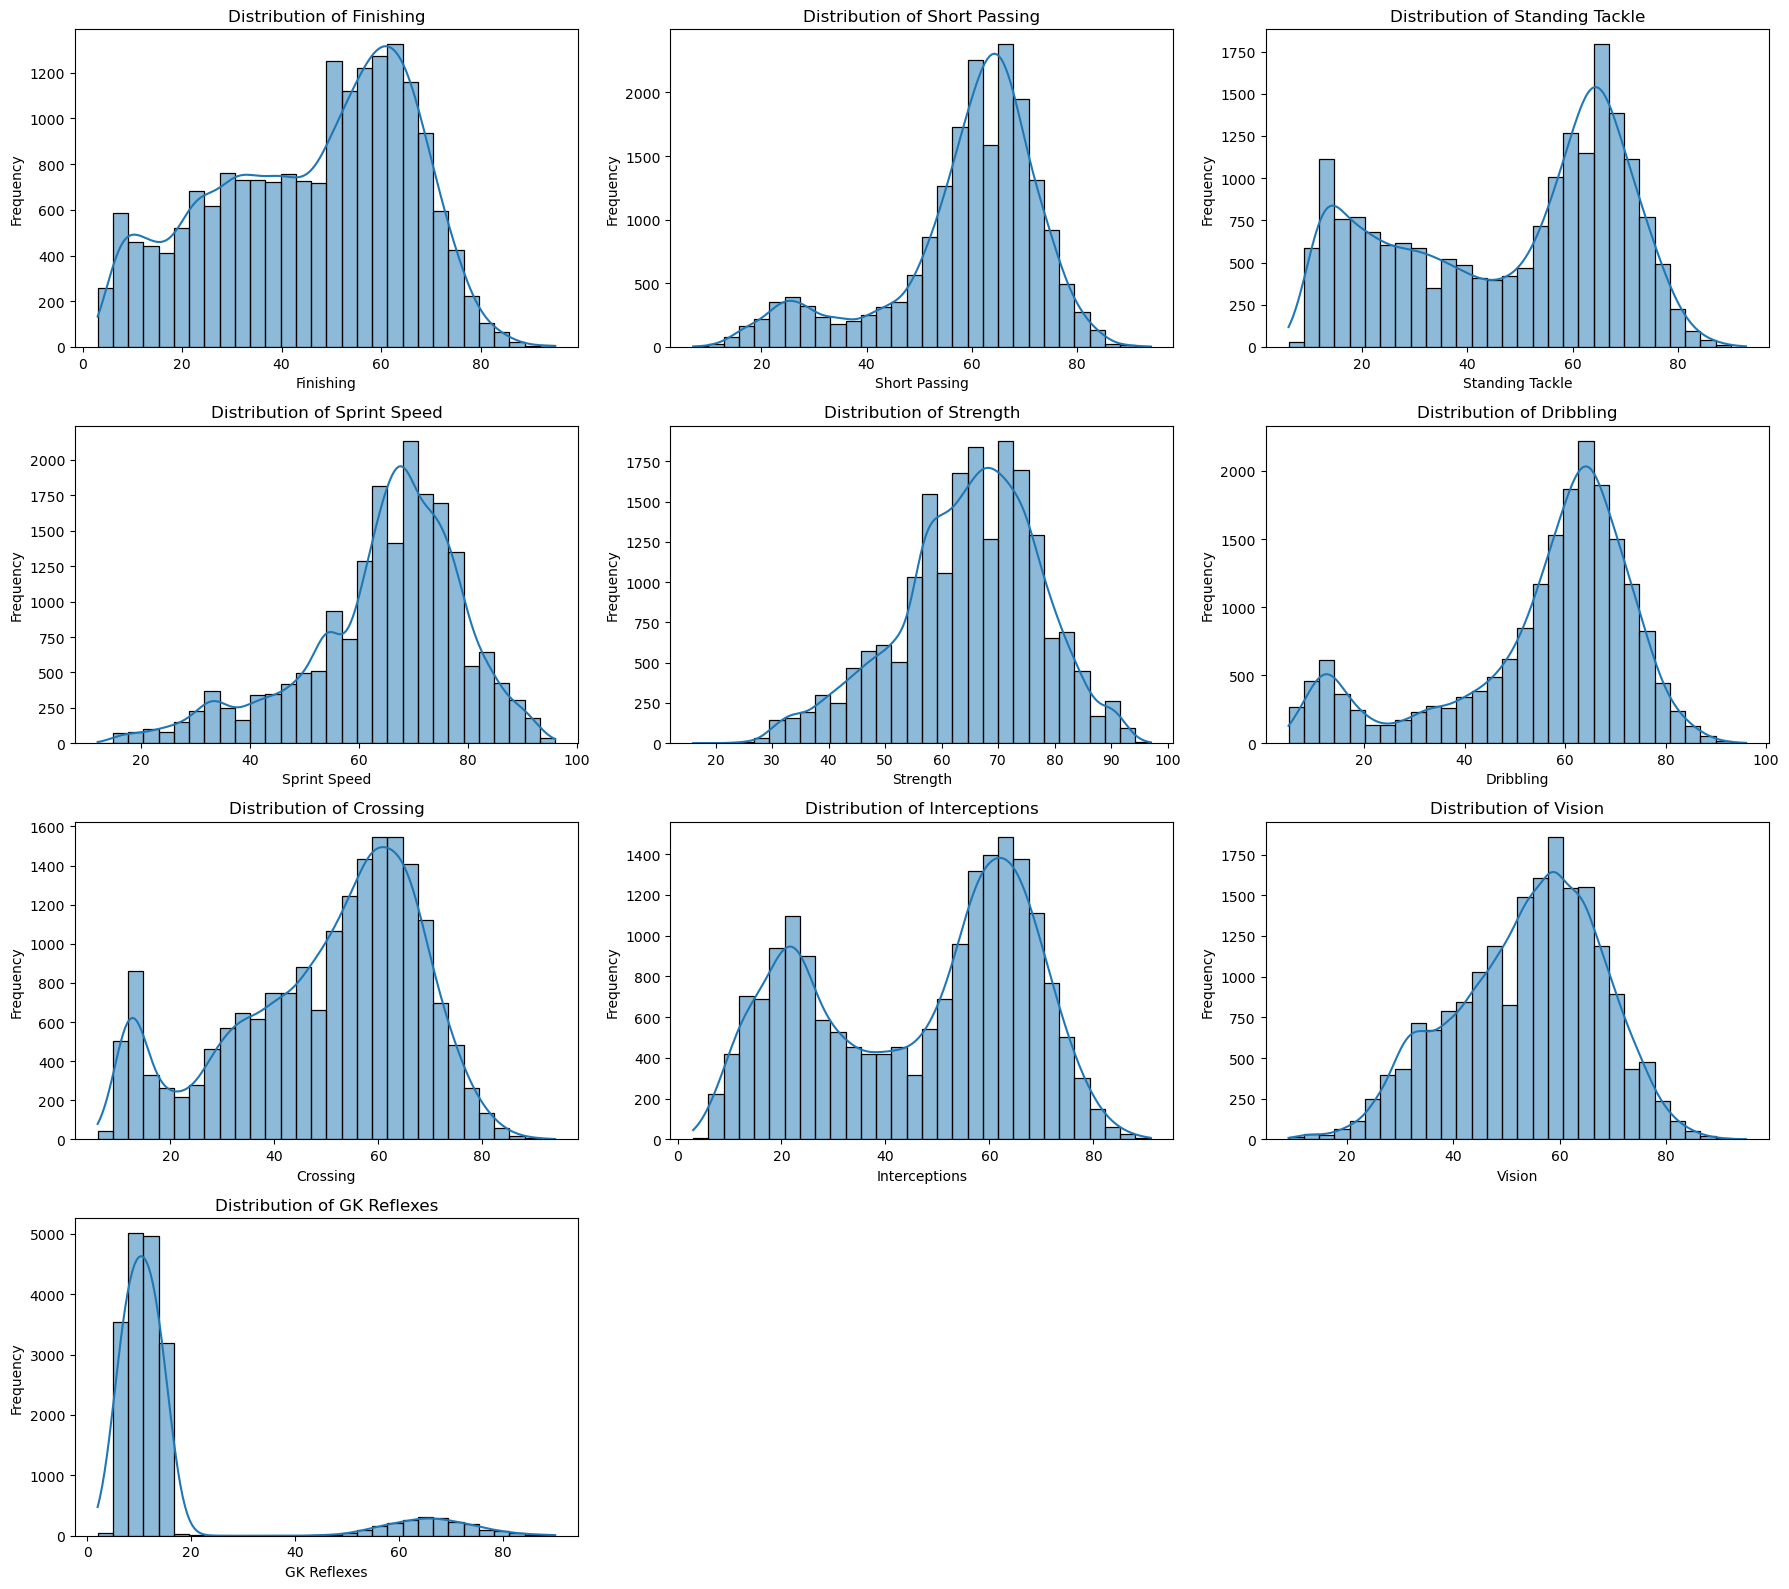

In [36]:
plot_feature_distributions(df_soccer_clustering, features_for_clustering)

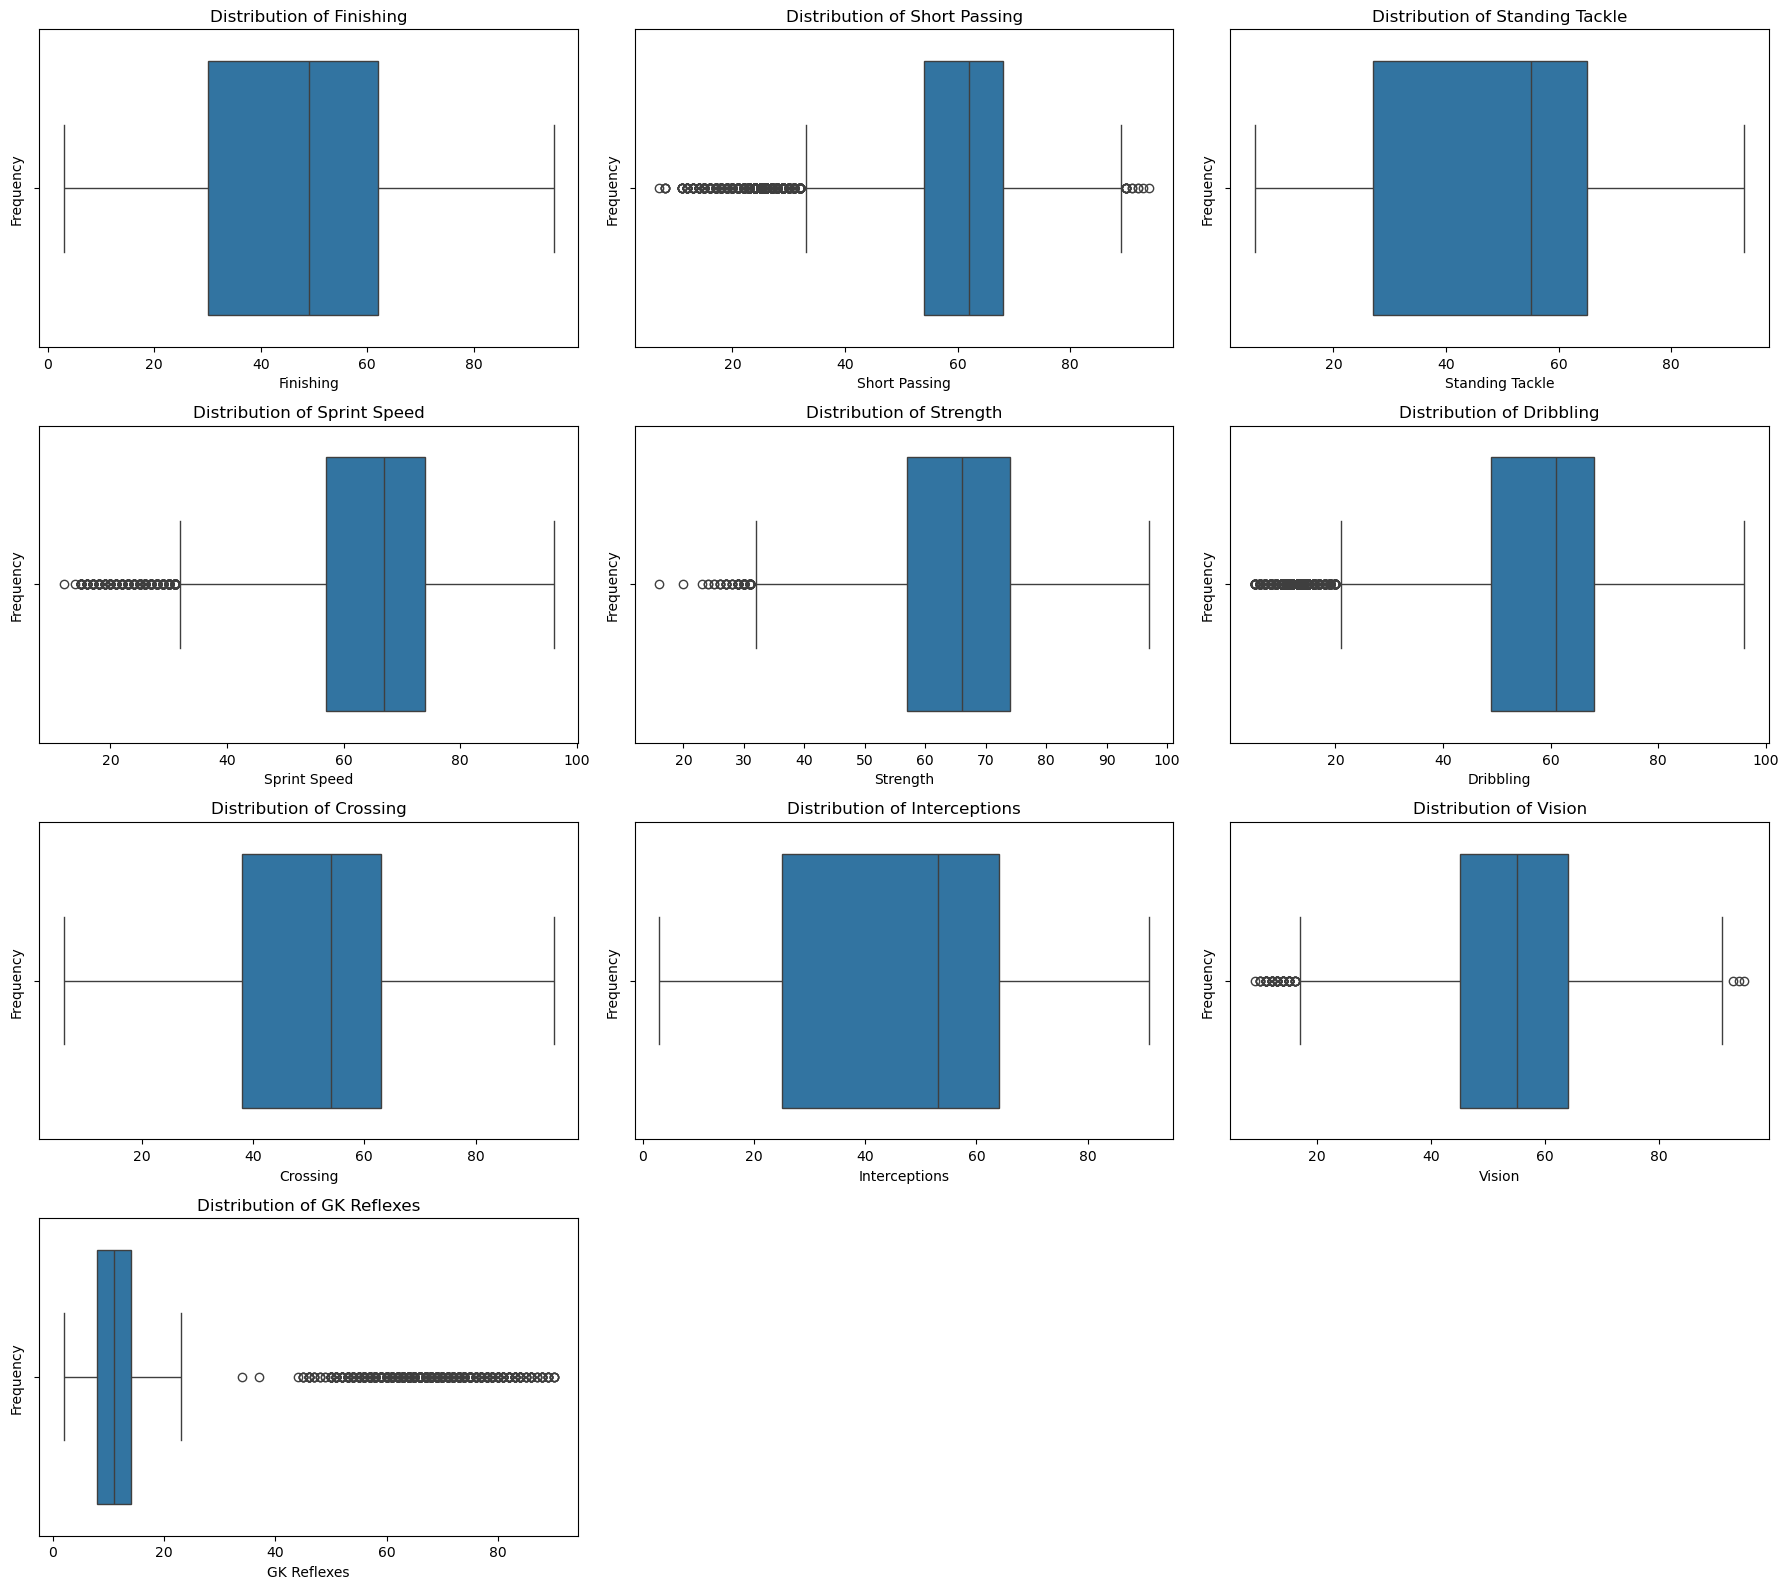

In [37]:
plot_feature_distributions(df_soccer_clustering, features_for_clustering, flag='box')

In [ ]:
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline

# 1. Build the preprocessing pipeline
preprocessor = Pipeline(steps=[
    ('power', PowerTransformer(method='yeo-johnson')),    # Fixes skewness
    ('scale', RobustScaler())    # Fixes outliers & scaling
])

X_processed = preprocessor.fit_transform(df_soccer_clustering)

NOTE: `log_transformer = FunctionTransformer(np.log1p)` is not a good option because the data skewed positively and negatively. **np.log1p only works for positively skewed data**

In [71]:
df_processed = pd.DataFrame(X_processed, columns=features_for_clustering)

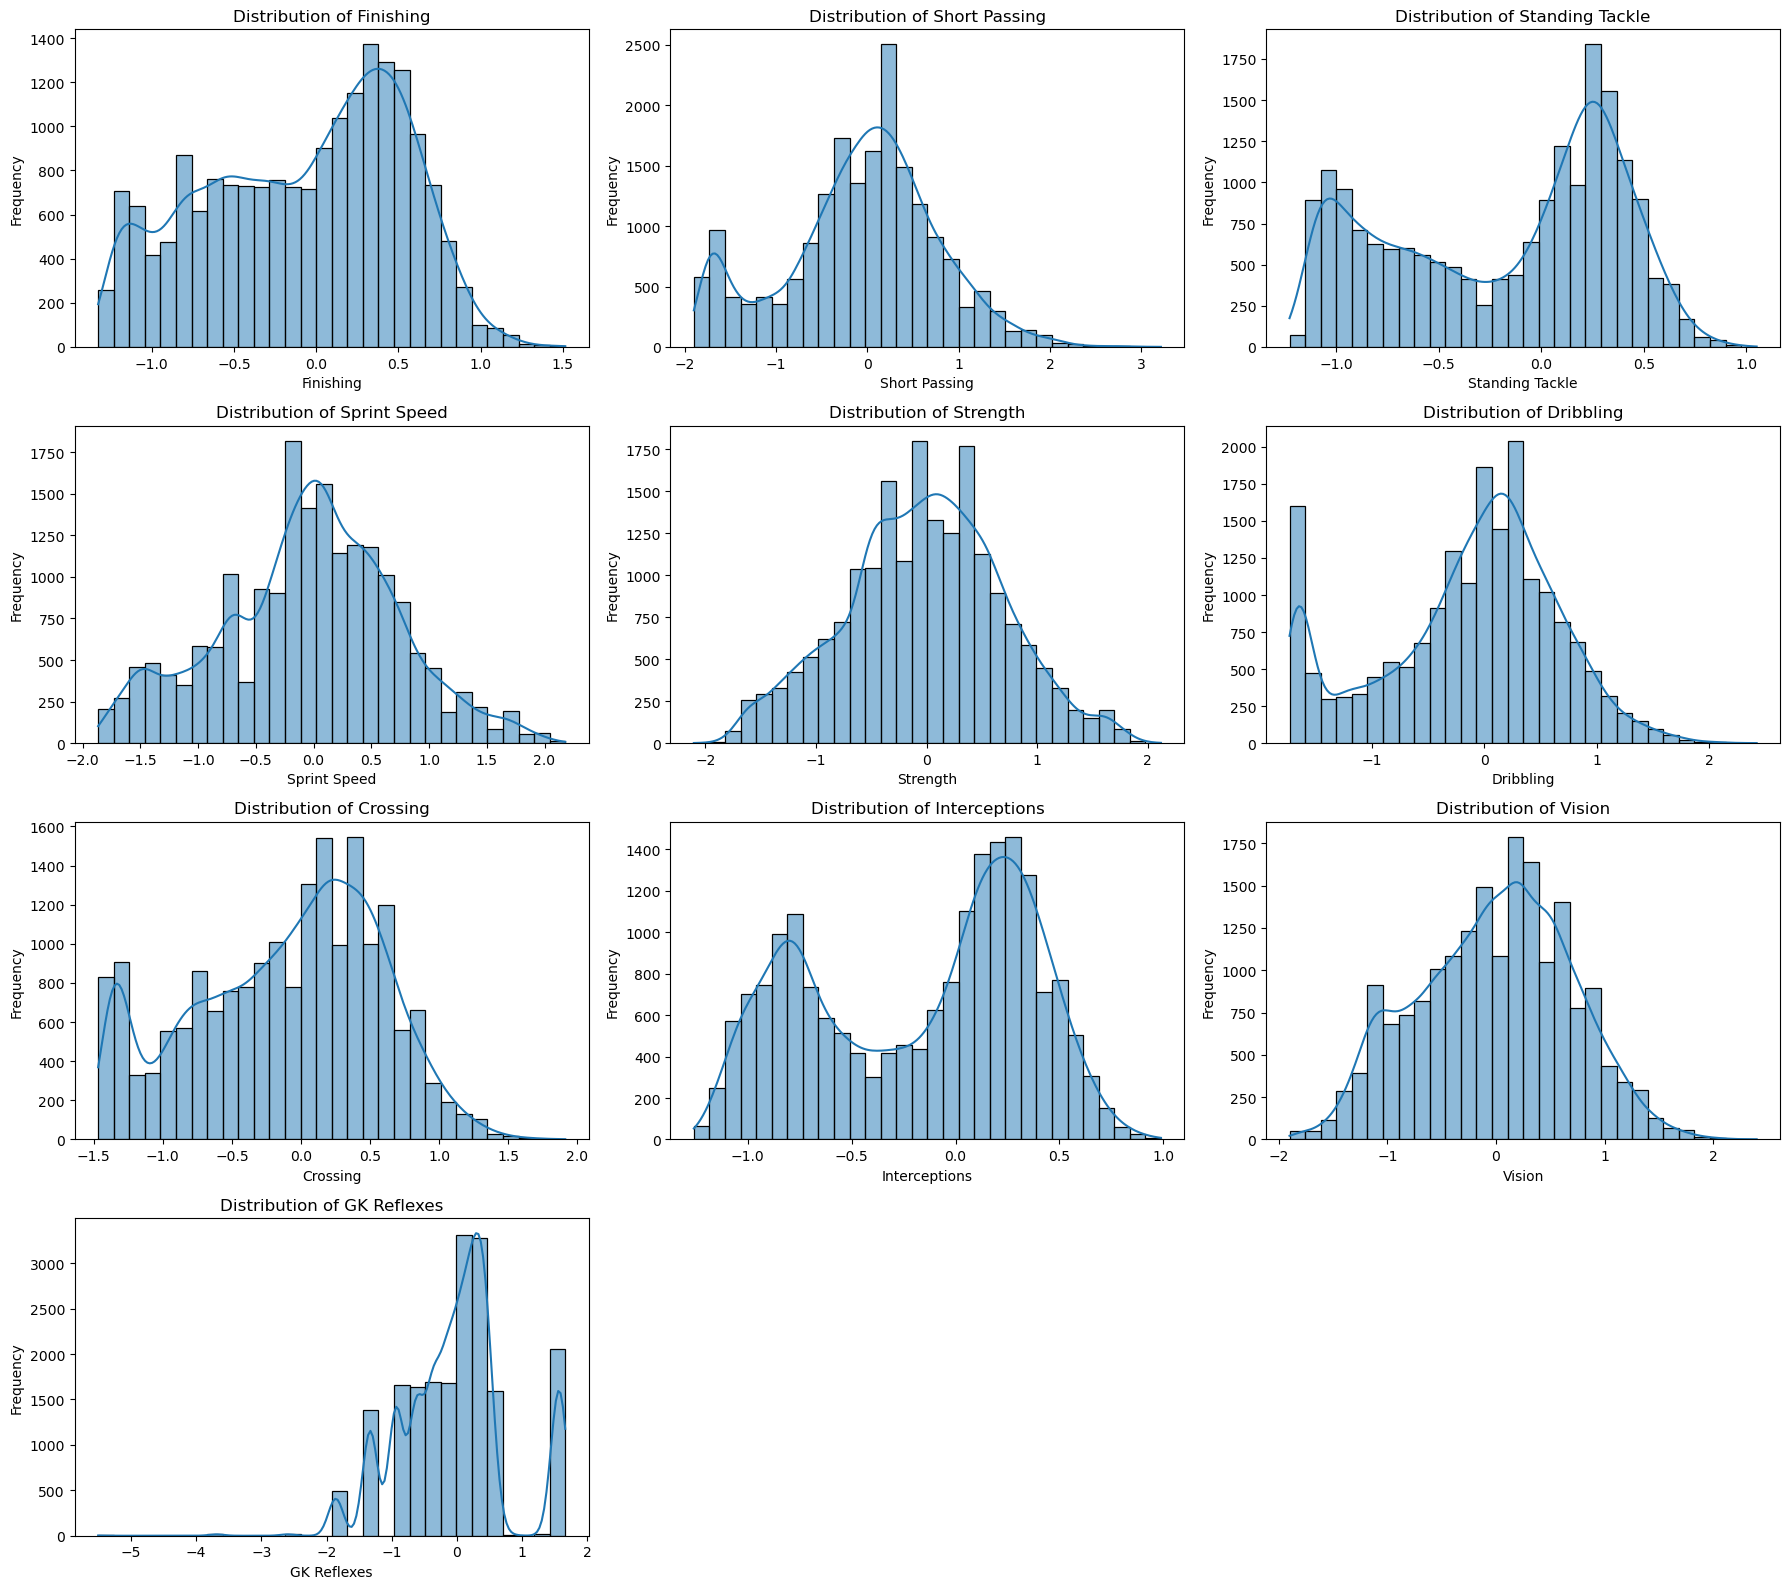

In [72]:
plot_feature_distributions(df_processed, df_processed.columns)

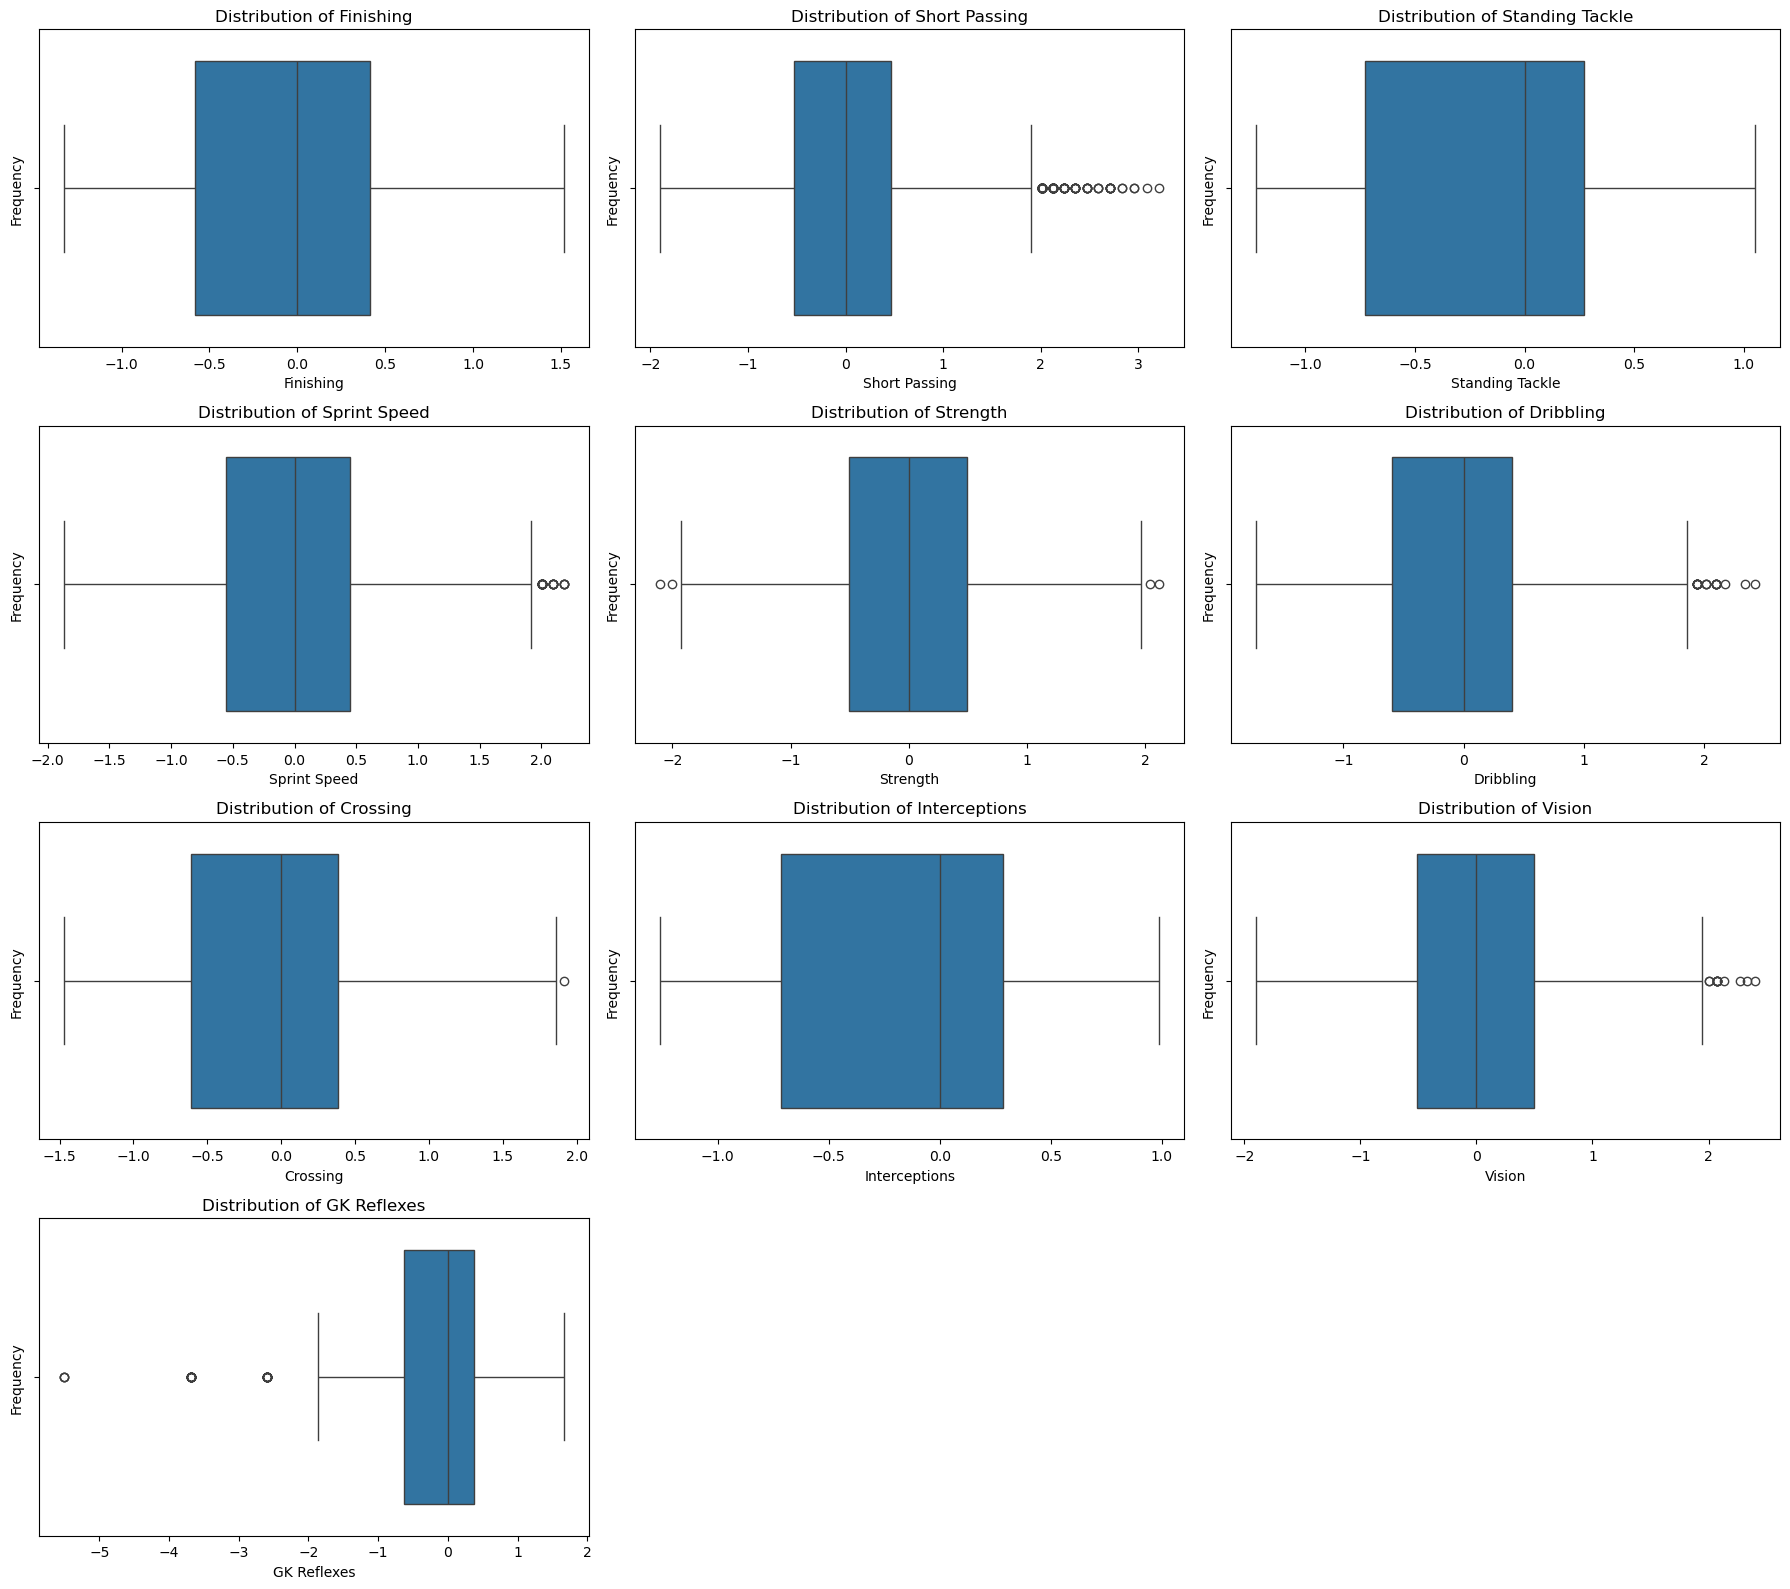

In [73]:
plot_feature_distributions(df_processed, df_processed.columns, flag='box')

#### Trying out Deleting outliers

In [74]:
df_processed_without_outliers = remove_outliers(df_processed, columns=df_processed.columns)

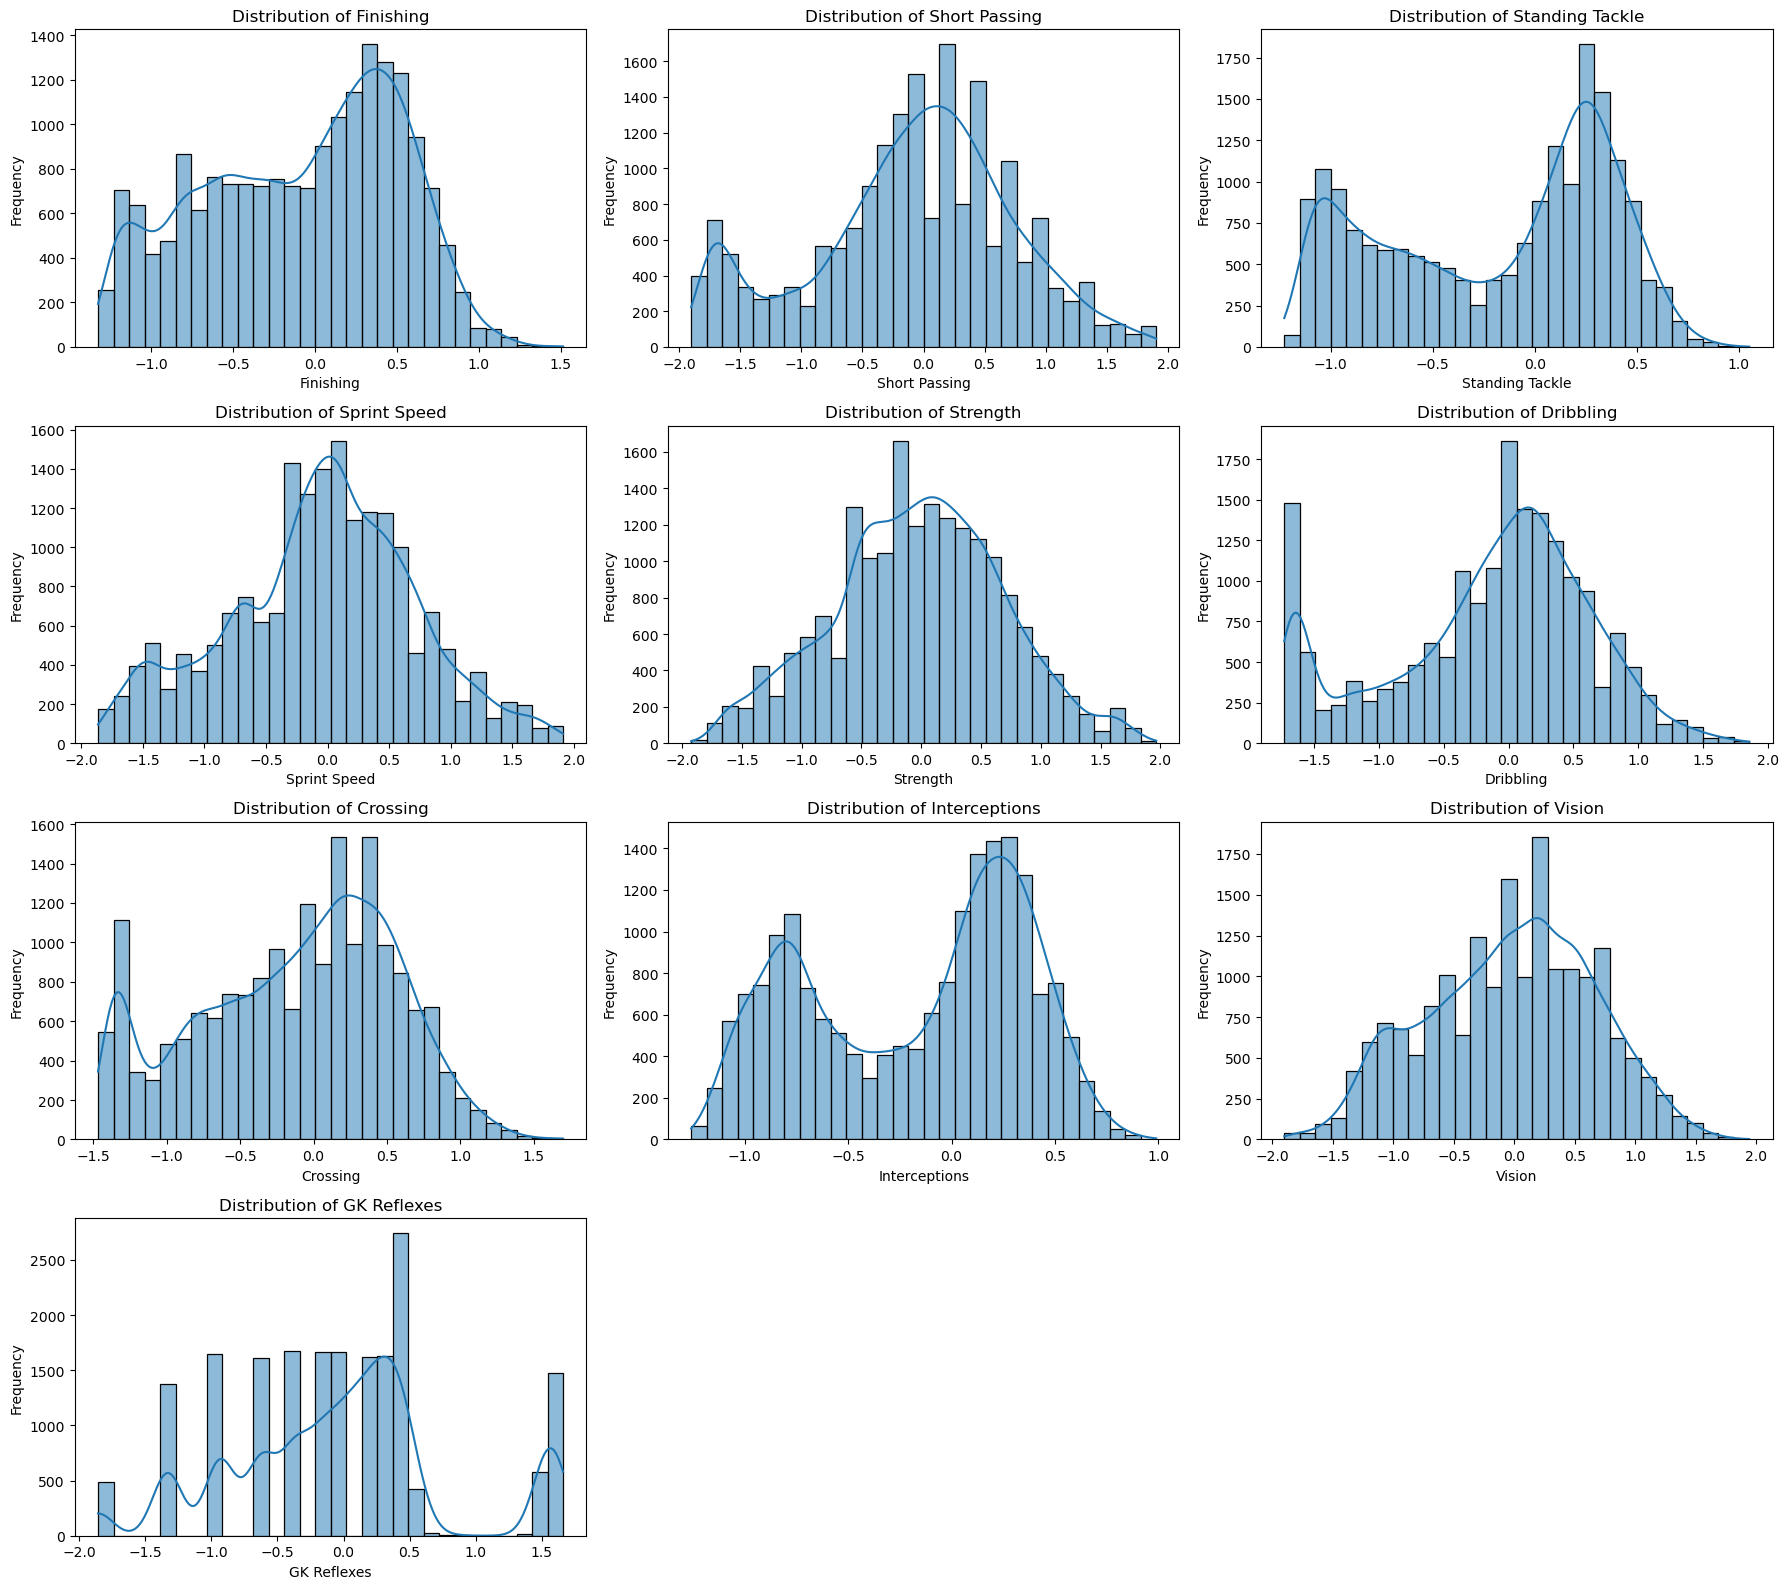

In [75]:
plot_feature_distributions(df_processed_without_outliers, features_for_clustering)

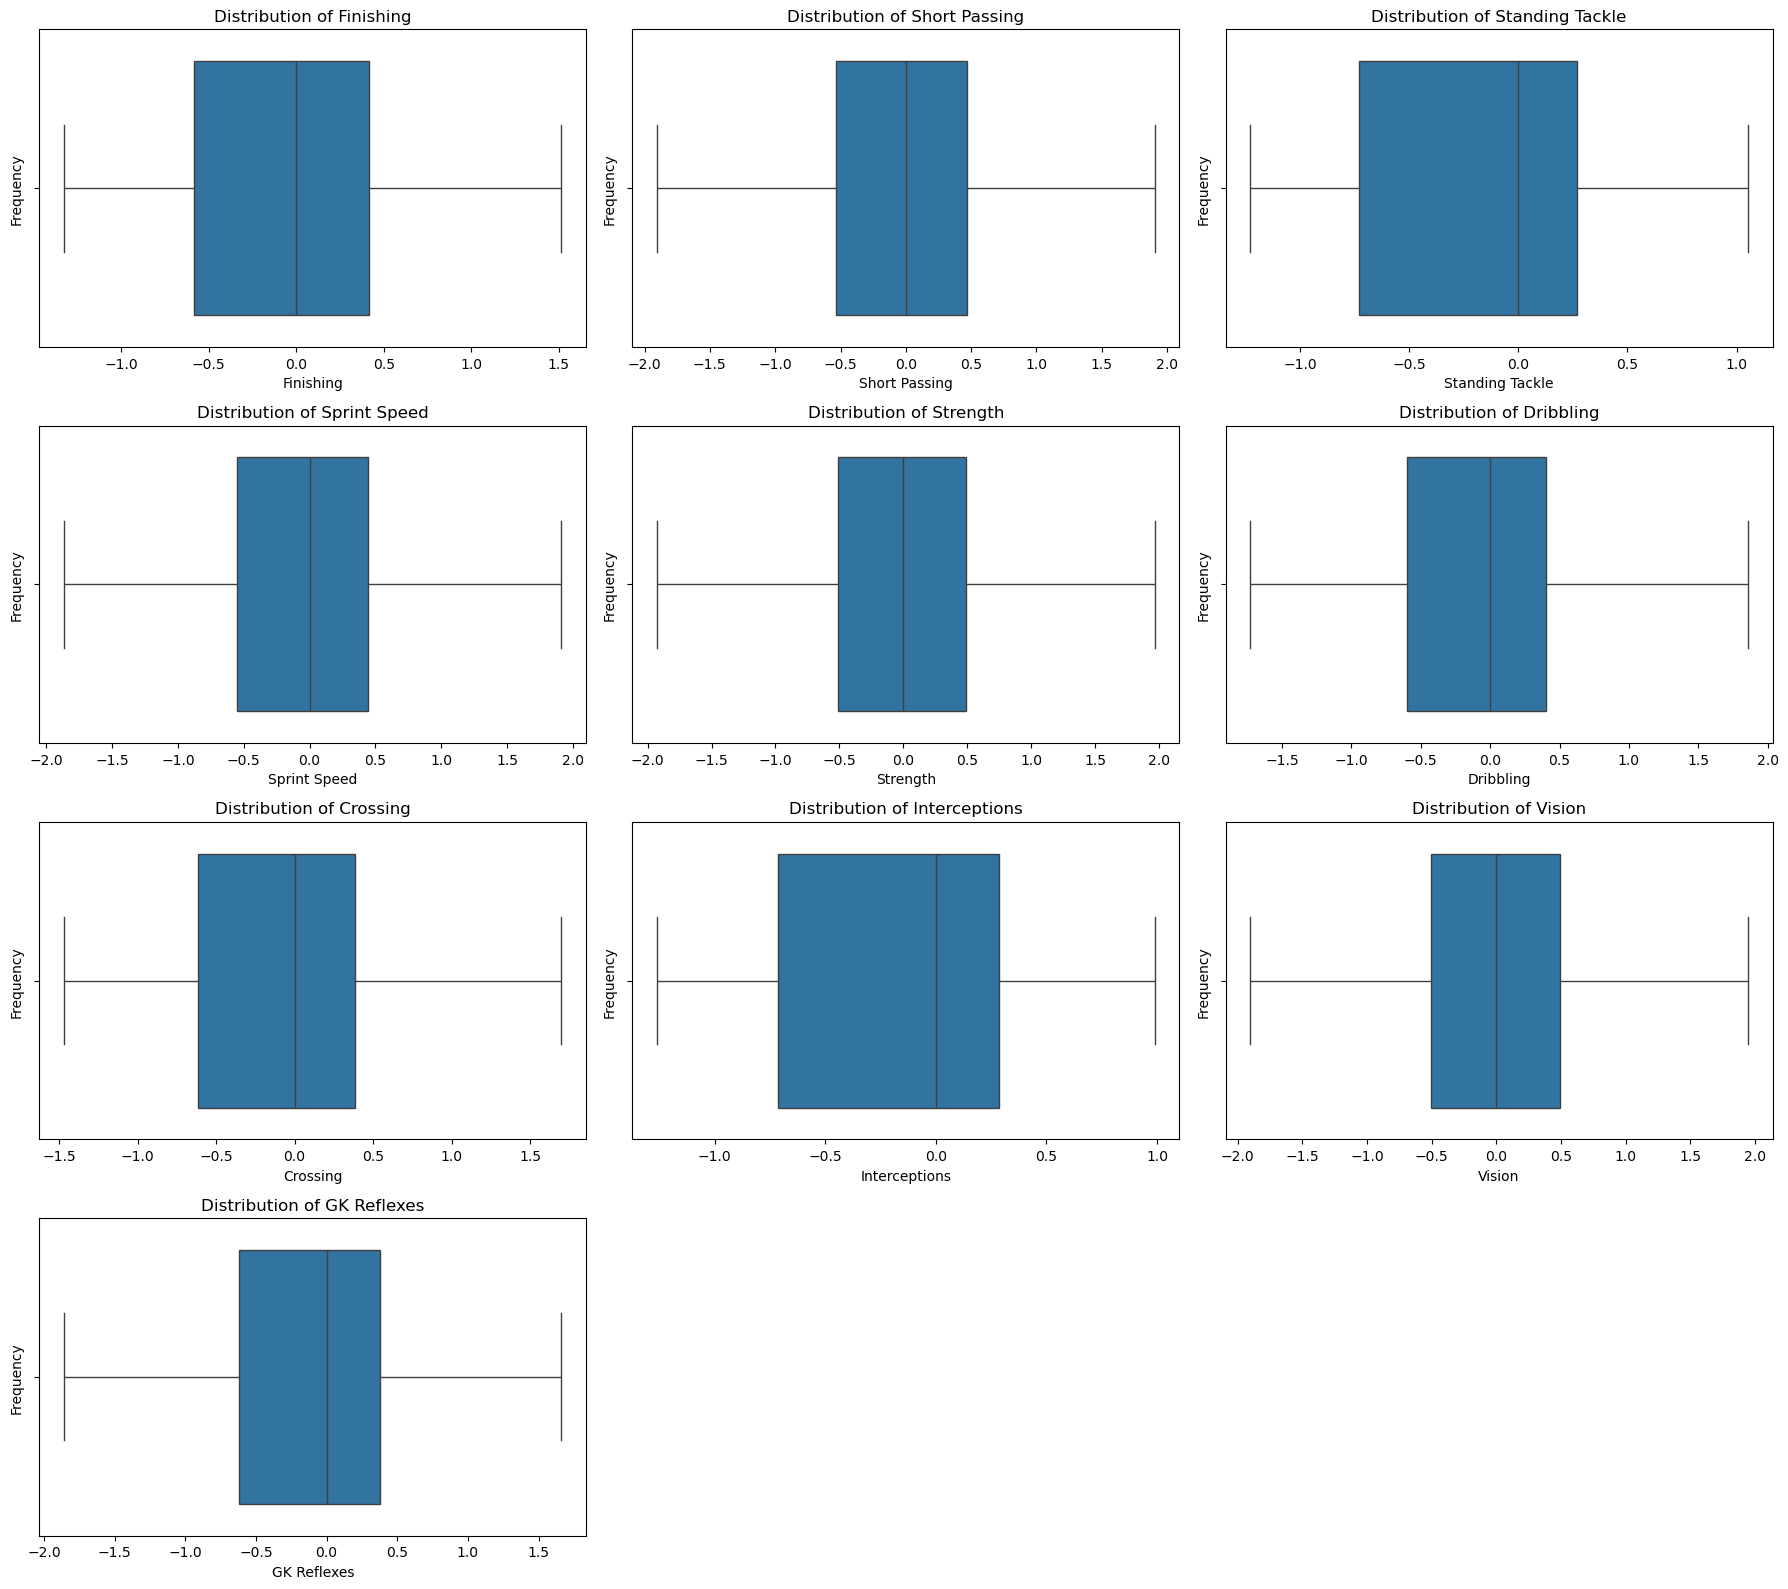

In [76]:
plot_feature_distributions(df_processed_without_outliers, features_for_clustering, flag='box')

### Multivariate Analysis

#### Multivariate Analysis without outliers

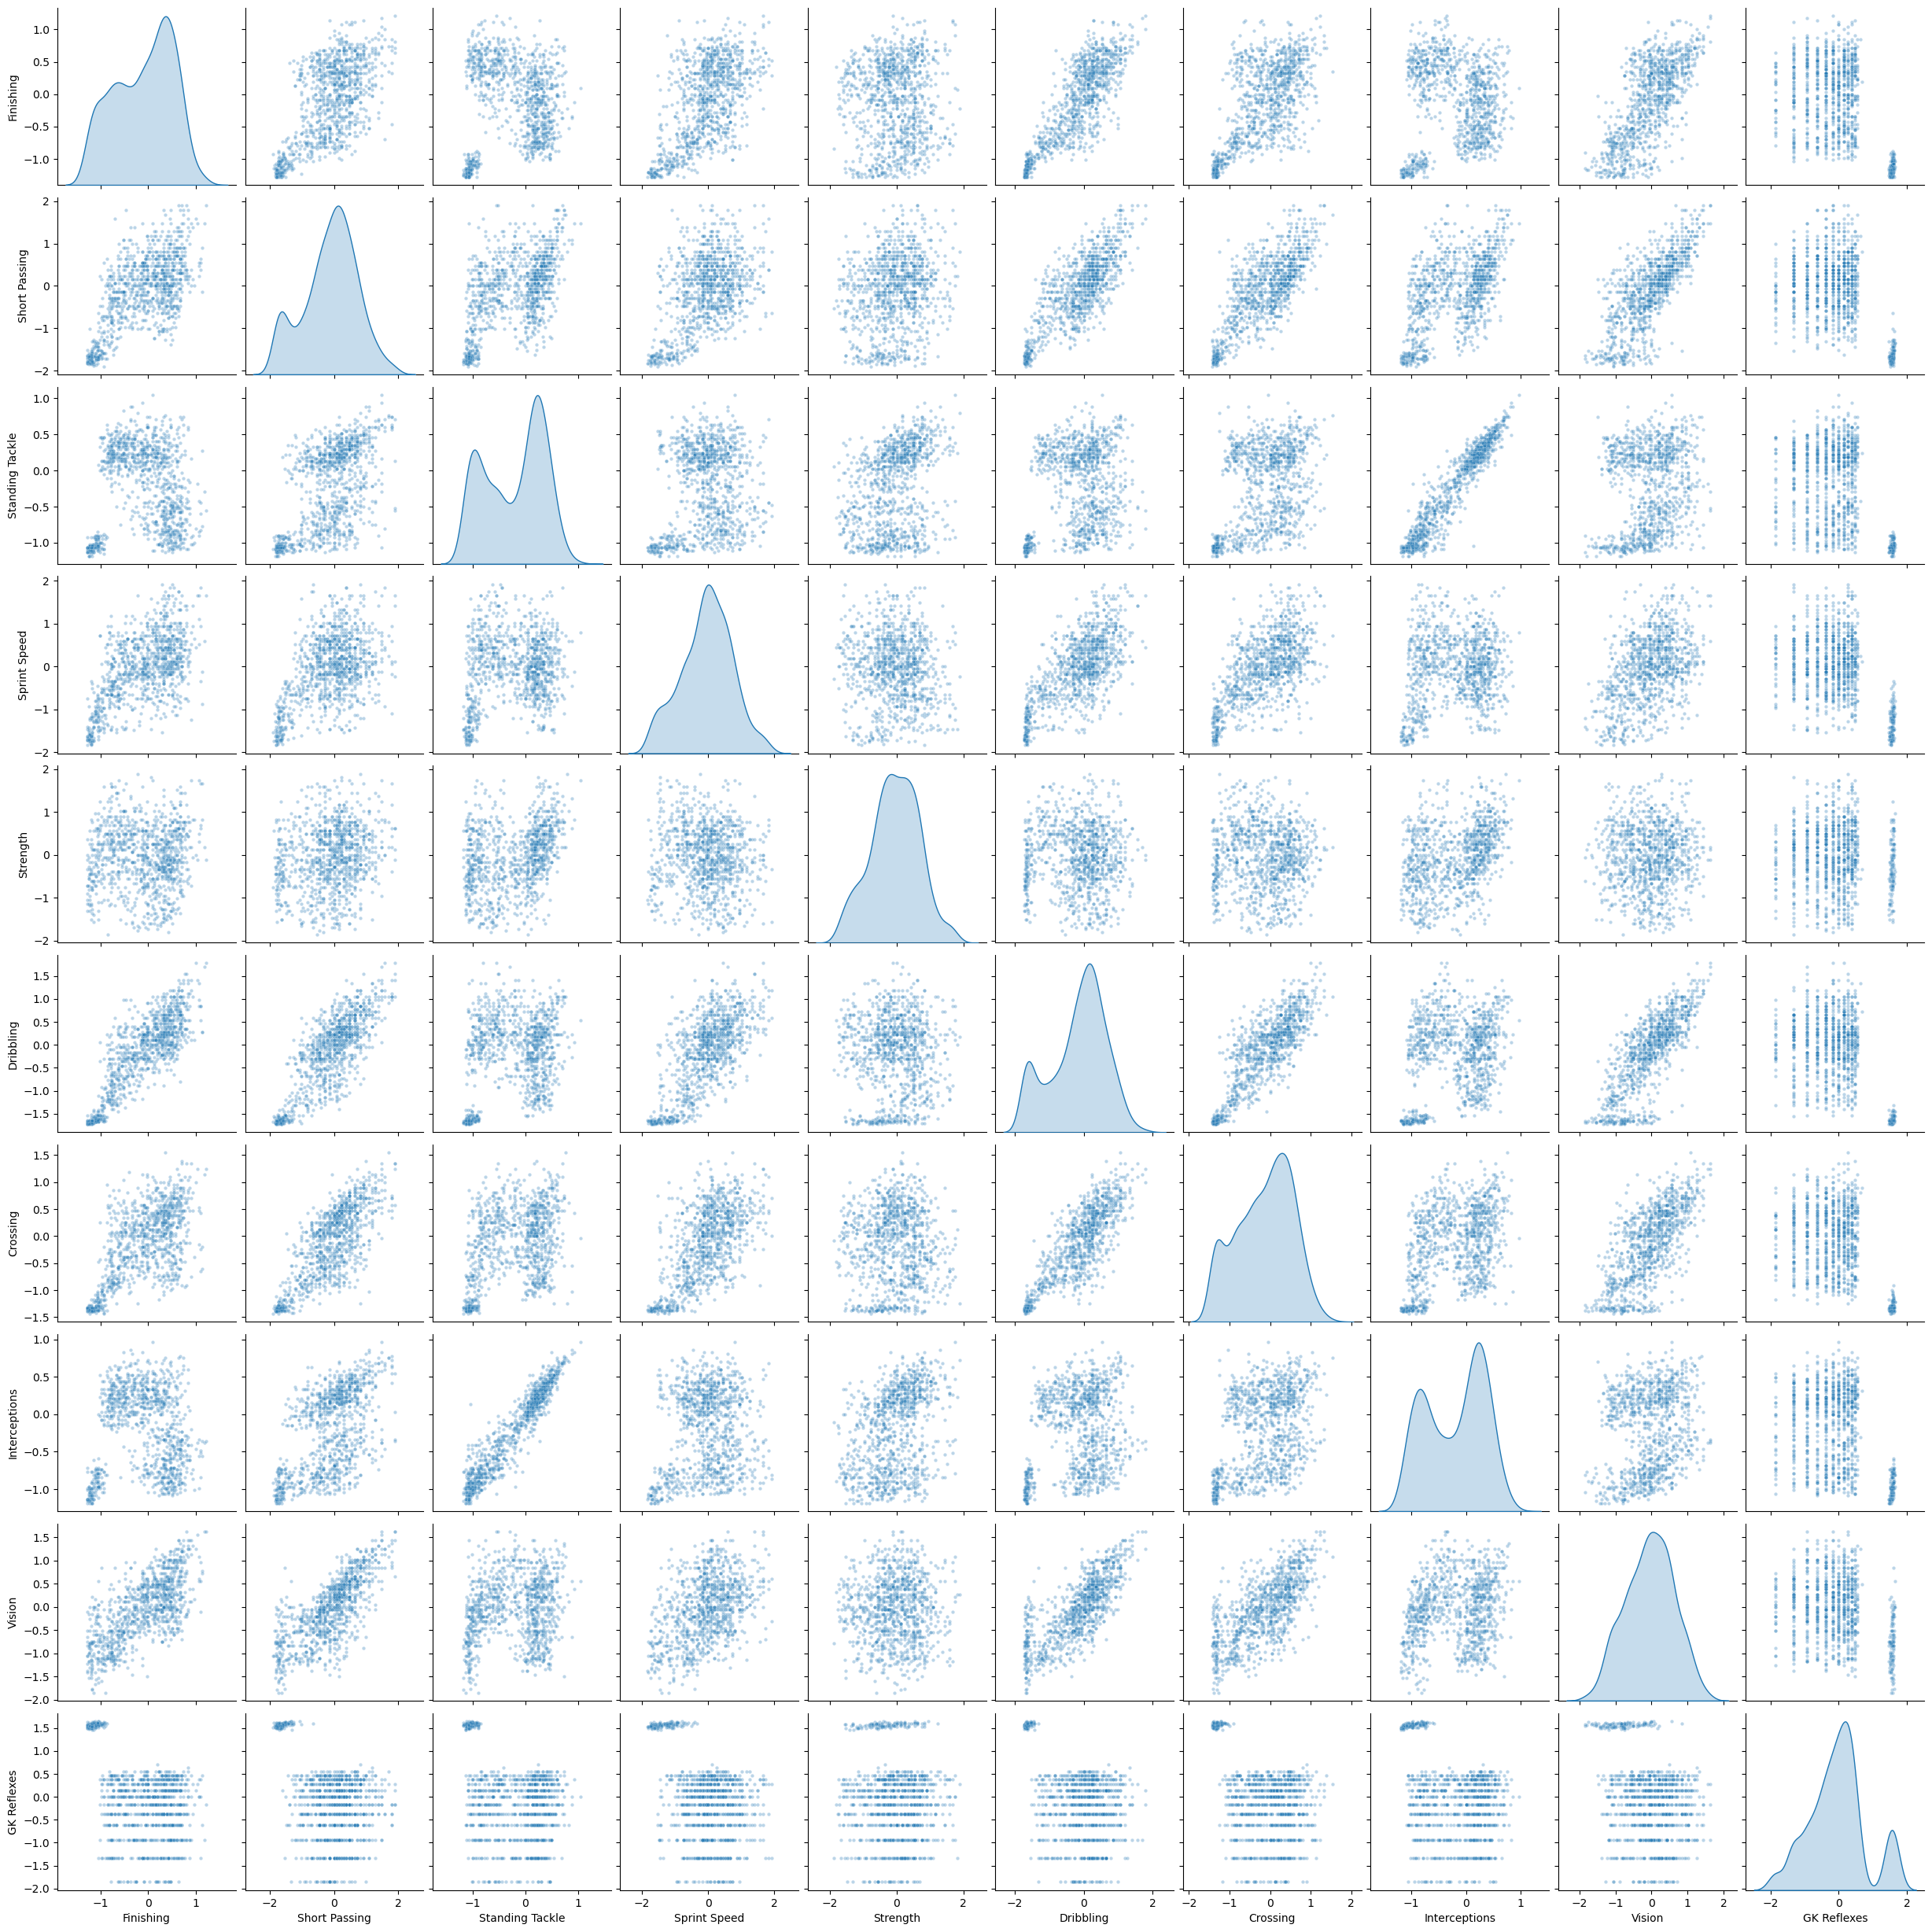

In [82]:
subset = ['Finishing', 'Standing Tackle', 'Sprint Speed', 'Short Passing']

sns.pairplot(df_processed_without_outliers[features_for_clustering].sample(1000), 
             diag_kind='kde', 
             plot_kws={'alpha': 0.3, 's': 10})
plt.show()

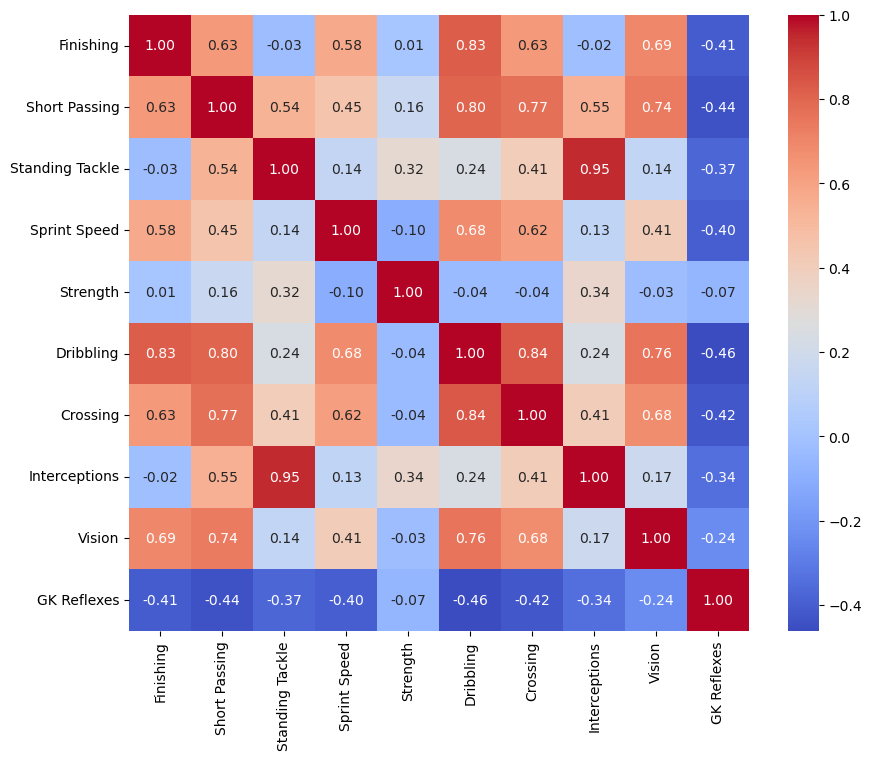

In [83]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed_without_outliers.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_processed_without_outliers)

# Plot the result
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, c='blue')
plt.title('All 10 Features compressed into 2 Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#### Multivariate Analysis with Outliers

In [ ]:
sns.pairplot(df_processed[features_for_clustering].sample(1000), 
             diag_kind='kde', 
             plot_kws={'alpha': 0.3, 's': 10})
plt.show()

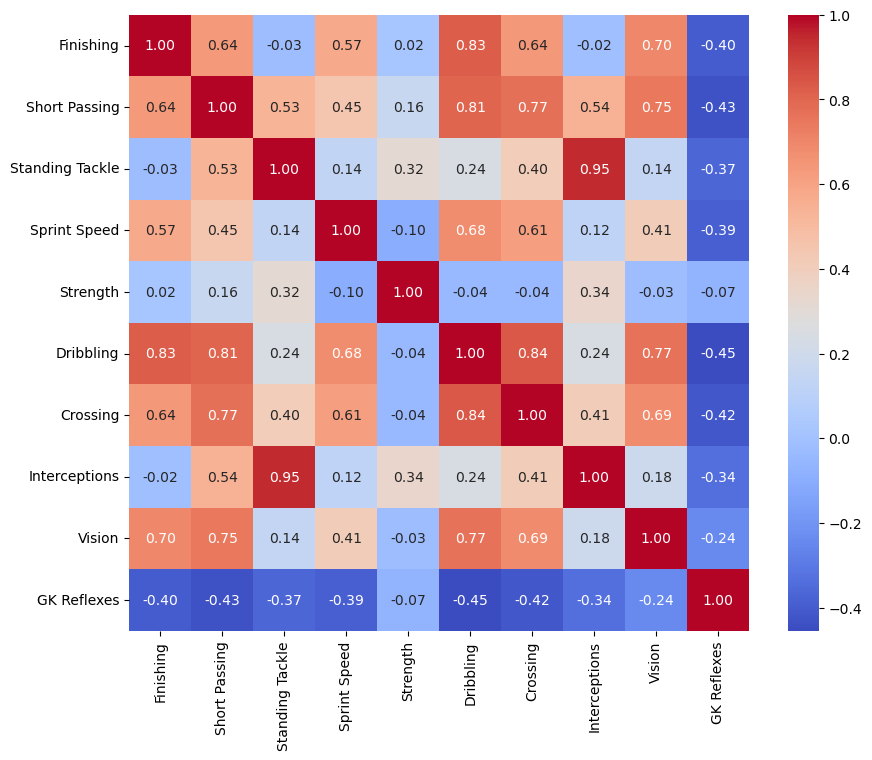

In [81]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

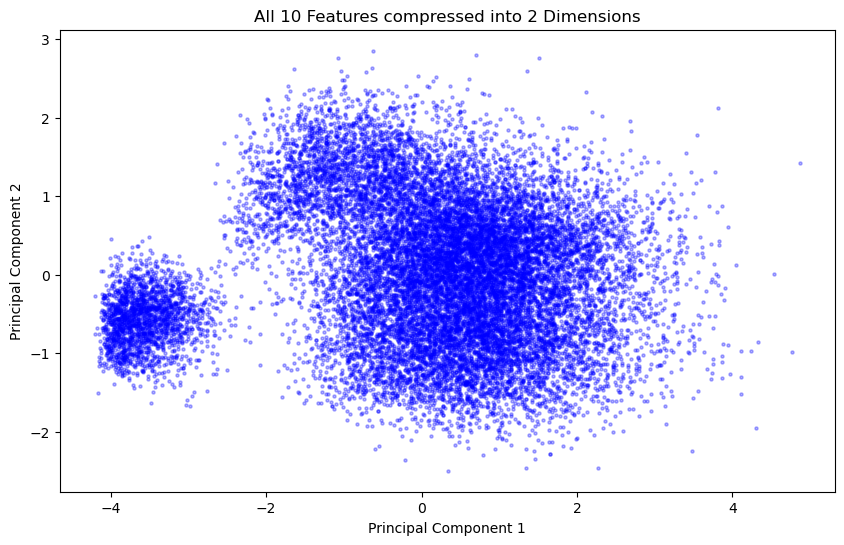

In [85]:

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_processed)

# Plot the result
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, c='blue')
plt.title('All 10 Features compressed into 2 Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [86]:
df_processed.to_csv('df_FIFA_cleaned_processed.csv', index=False)

## Cleaning Airplane Dataset

In [66]:
df_airplanes = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

In [67]:
df_airplanes.head(10)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
5,6,16420,0,1,1,1,0,0,0,0,6942,0
6,7,84914,0,3,1,1,27482,25,0,0,6994,0
7,8,20856,0,1,1,1,5250,4,250,1,6938,1
8,9,443003,0,3,2,1,1753,43,3850,12,6948,1
9,10,104860,0,3,1,1,28426,28,1150,3,6931,1


In [69]:
df_airplanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [70]:
df_airplanes.drop(columns=['ID#'], inplace=True)

In [ ]:
df_airplanes["Award?"].value_counts()

Award?
0    2518
1    1481
Name: count, dtype: int64

In [77]:
df_airplanes.drop(columns=['Award?'], inplace=True)

In [78]:
df_airplanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
dtypes: int64(10)
memory usage: 312.6 KB


### Univariate Analysis

In [89]:
def plotting_hist_box_of_data(df: pd.DataFrame, columns: list, flag:str):
    fig, axes = plt.subplots(5,2,figsize=(20,30))
    axes = axes.flatten()
    
    for index, feature in enumerate(columns):
        sns.histplot(data=df, x=feature,kde=True, ax=axes[index], bins=30)
        axes[index].set_title(feature, fontsize=11)
        
    plt.suptitle('Histogram of all features', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

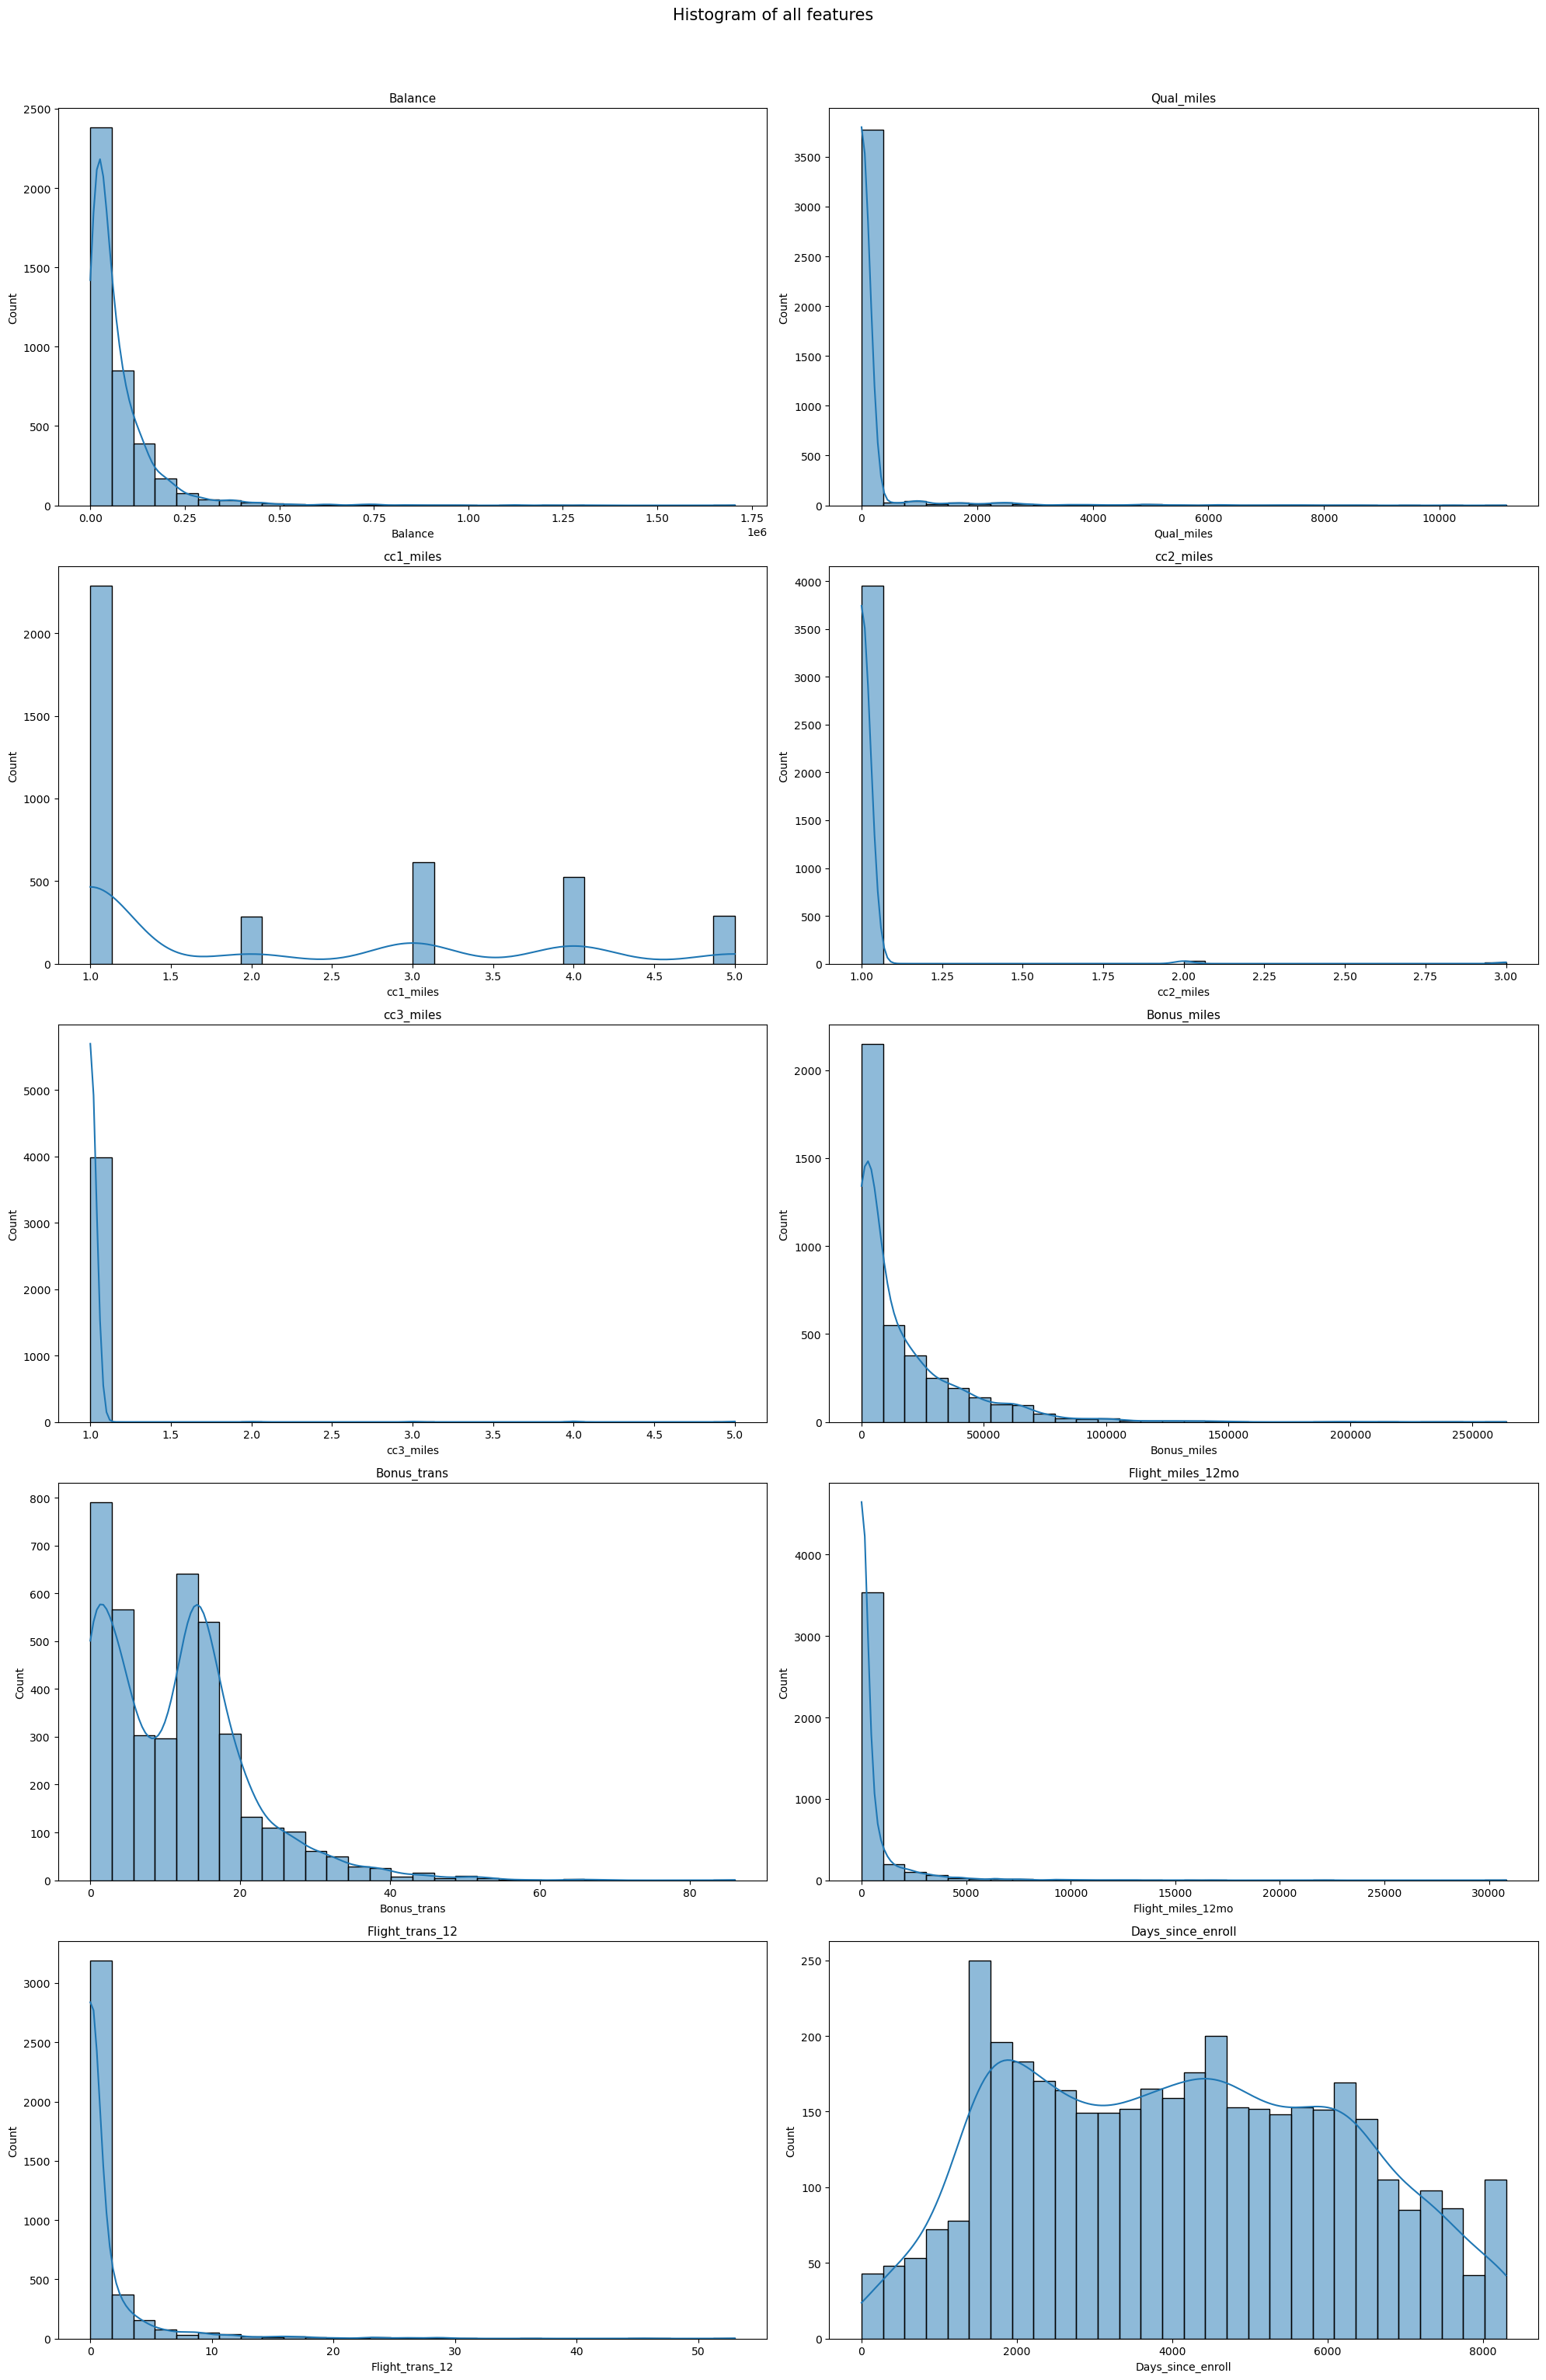

In [90]:
plotting_hist_box_of_data(df_airplanes,df_airplanes.columns.to_list(),"hist")

# Implementing GMM algorithm from Scratch

## FIFA

In [2]:
df_soccer = pd.read_csv('df_FIFA_cleaned_processed.csv')

In [10]:
# Set random seed for reproducibility
np.random.seed(42)

K = 3  # Number of clusters
n, d = df_soccer.shape
print("Number of samples (n):", n)
print("Number of features (d):", d)
epsilon = 1e-6  # Small value to prevent log(0)

# Mixing coefficients (initial uniform distribution)
pi = np.ones(K) / K

Number of samples (n): 18852
Number of features (d): 10


In [7]:
random_indices = np.random.choice(n, K, replace=False)
random_indices

array([15231,  5128,  5222])

In [26]:
mu = df_soccer.iloc[random_indices,:].to_numpy()  # Initial means based on random samples
mu

array([[ 0.25466544,  0.        , -0.13367631,  0.58374679, -0.56027965,
         0.22554399, -0.2806414 , -0.18021918,  0.26938463,  0.26880958],
       [-0.24985106,  0.2262098 ,  0.40803345, -0.17639937,  1.23281317,
        -0.92706191, -0.57820067,  0.3365105 , -0.4100061 , -0.17049918],
       [-1.12423895, -1.50996988, -1.09191344, -1.36635663,  0.49288231,
        -1.66302025, -1.37903712, -0.8912602 , -1.05829391,  1.59738317]])

In [11]:
# Function to generate a positive definite covariance matrix
def generate_positive_definite_matrix(d):
    A = np.random.randn(d, d) #This generates a random matrix A of size d x d with values drawn from a standard normal distribution.
    return np.dot(A, A.T) + np.eye(d) * epsilon  # Add identity for stability

In [15]:
# Initialize covariance matrices
Sigma = np.array([generate_positive_definite_matrix(d) for _ in range(K)])
Sigma.shape

(3, 10, 10)

In [16]:
# Ensure covariance matrix is positive definite
def ensure_positive_definite(Sigma):
    return Sigma + np.eye(Sigma.shape[0]) * epsilon

In [19]:
from scipy.stats import multivariate_normal

# Expectation Step (E-step)
def expectation_step(X, mu, Sigma, pi):
    """ Compute responsibilities (γ) given current parameters. """
    gamma = np.zeros((n, K))
    for k in range(K):
        try:
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=ensure_positive_definite(Sigma[k]))
        except np.linalg.LinAlgError:
            print(f"Warning: Fixing singular covariance matrix for cluster {k}")
            Sigma[k] = ensure_positive_definite(Sigma[k])
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k])

    gamma += epsilon  # Prevents division by zero
    gamma /= gamma.sum(axis=1, keepdims=True)  # Normalize
    return gamma

In [20]:
# Maximization Step (M-step)
def maximization_step(X, gamma):
    """ Update parameters based on responsibilities. """
    Nk = gamma.sum(axis=0)  # Effective cluster size
    pi_new = Nk / n  # Update mixing coefficients
    mu_new = np.dot(gamma.T, X) / Nk[:, np.newaxis]  # Update means

    Sigma_new = np.zeros((K, d, d))
    for k in range(K):
        X_centered = X - mu_new[k]
        Sigma_new[k] = np.dot(gamma[:, k] * X_centered.T, X_centered) / Nk[k]
        Sigma_new[k] = ensure_positive_definite(Sigma_new[k])  # Ensure positive definiteness

    return pi_new, mu_new, Sigma_new

In [21]:
# Compute Log-Likelihood
def compute_log_likelihood(X, pi, mu, Sigma):
    """ Compute the Log-Likelihood to monitor convergence. """
    log_likelihood = 0
    for k in range(K):
        try:
            prob = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=ensure_positive_definite(Sigma[k]))
            prob += epsilon  # Prevents log(0)
            log_likelihood += np.sum(np.log(prob))
        except np.linalg.LinAlgError:
            print(f"Warning: Fixing covariance matrix for cluster {k}")
            Sigma[k] = ensure_positive_definite(Sigma[k])
            prob = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k]) + epsilon
            log_likelihood += np.sum(np.log(prob))

    return log_likelihood

Iteration 1, Log-Likelihood: -388118.0850
Iteration 2, Log-Likelihood: -388122.5024
Iteration 3, Log-Likelihood: -388161.1399
Iteration 4, Log-Likelihood: -388525.7940
Iteration 5, Log-Likelihood: -391869.5863
Iteration 6, Log-Likelihood: -400883.6513
Iteration 7, Log-Likelihood: -414765.4175
Iteration 8, Log-Likelihood: -427761.5815
Iteration 9, Log-Likelihood: -441844.6275
Iteration 10, Log-Likelihood: -458398.7940
Iteration 11, Log-Likelihood: -478932.5299
Iteration 12, Log-Likelihood: -502787.6584
Iteration 13, Log-Likelihood: -525895.6415
Iteration 14, Log-Likelihood: -539878.1704
Iteration 15, Log-Likelihood: -546422.2353
Iteration 16, Log-Likelihood: -549837.9594
Iteration 17, Log-Likelihood: -552055.4536
Iteration 18, Log-Likelihood: -553736.6102
Iteration 19, Log-Likelihood: -555094.8691
Iteration 20, Log-Likelihood: -556207.4098
Iteration 21, Log-Likelihood: -557114.2193
Iteration 22, Log-Likelihood: -557845.9754
Iteration 23, Log-Likelihood: -558430.3908
Iteration 24, Log-Li

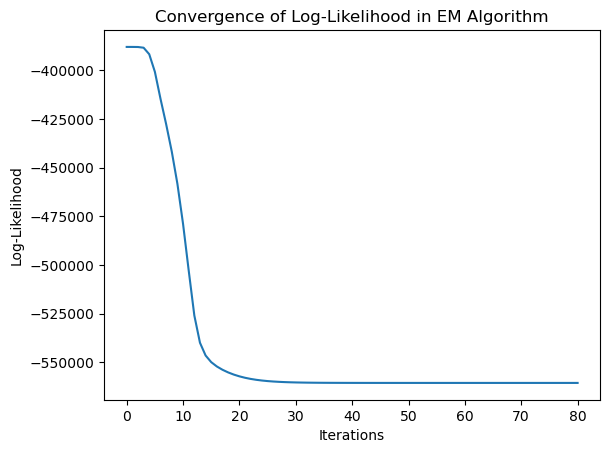

In [27]:
# EM Algorithm for GMM
max_iters = 100  # Maximum iterations
tol = 1e-4  # Convergence threshold
log_likelihoods = []
prev_log_likelihood = -np.inf  # Initialize with a very low value

for i in range(max_iters):
    gamma = expectation_step(df_soccer.to_numpy(), mu, Sigma, pi)
    pi, mu, Sigma = maximization_step(df_soccer.to_numpy(), gamma)

    # Compute log-likelihood
    log_likelihood = compute_log_likelihood(df_soccer.to_numpy(), pi, mu, Sigma)
    log_likelihoods.append(log_likelihood)

    print(f"Iteration {i+1}, Log-Likelihood: {log_likelihood:.4f}")

    # Check for convergence
    if np.abs(log_likelihood - prev_log_likelihood) < tol:
        print(f"Converged at iteration {i+1}.")
        break
    prev_log_likelihood = log_likelihood

# Plot log-likelihood evolution
plt.plot(log_likelihoods)
plt.xlabel('Iterations')
plt.ylabel('Log-Likelihood')
plt.title('Convergence of Log-Likelihood in EM Algorithm')
plt.show()



In [37]:
features_for_clustering = [
    'Finishing',
    'Short Passing',
    'Standing Tackle',
    'Sprint Speed',
    'Strength',
    'Dribbling',
    'Crossing',
    'Interceptions',
    'Vision',
    'GK Reflexes'
]

In [47]:
gamma

array([[5.25919097e-01, 2.37040452e-01, 2.37040452e-01],
       [9.72950569e-01, 1.35247153e-02, 1.35247153e-02],
       [2.45565519e-04, 2.45565519e-04, 9.99508869e-01],
       ...,
       [1.29428362e-03, 9.98471270e-01, 2.34445905e-04],
       [9.98716189e-01, 6.23914295e-04, 6.59896765e-04],
       [1.65682284e-03, 6.96307595e-02, 9.28712418e-01]])

In [65]:
# Assign each point to its most likely cluster
cluster_labels = np.argmax(gamma, axis=1)

# Add cluster labels to a copy of the dataframe
df_clustered = df_soccer.copy()
df_clustered['Cluster'] = cluster_labels

colors = ['#e74c3c', '#3498db', '#2ecc71']

In [48]:
df_clustered.head()

,Finishing,Short Passing,Standing Tackle,Sprint Speed,Strength,Dribbling,Crossing,Interceptions,Vision,GK Reflexes,Cluster
0,1.515166,2.835984,-0.526155,0.869715,0.180269,2.419793,1.440356,-0.334052,2.400562,-0.623331,0
1,1.515166,1.796169,-0.602847,1.741445,0.753743,1.778358,1.389326,-0.614233,1.562314,0.000000,0
2,-1.124239,-1.106170,-1.091913,-0.397606,0.753743,-1.663020,-1.337373,-0.866243,0.548278,1.661744,2
3,1.075732,3.216192,0.270939,0.583747,0.492882,1.778358,1.912162,0.336511,2.334274,0.268810,0
4,1.243843,2.355368,-0.653585,1.573577,-0.865504,2.336773,1.440356,-0.436236,2.072082,0.000000,0


### 1. PCA Scatter Plot (2D Projection)

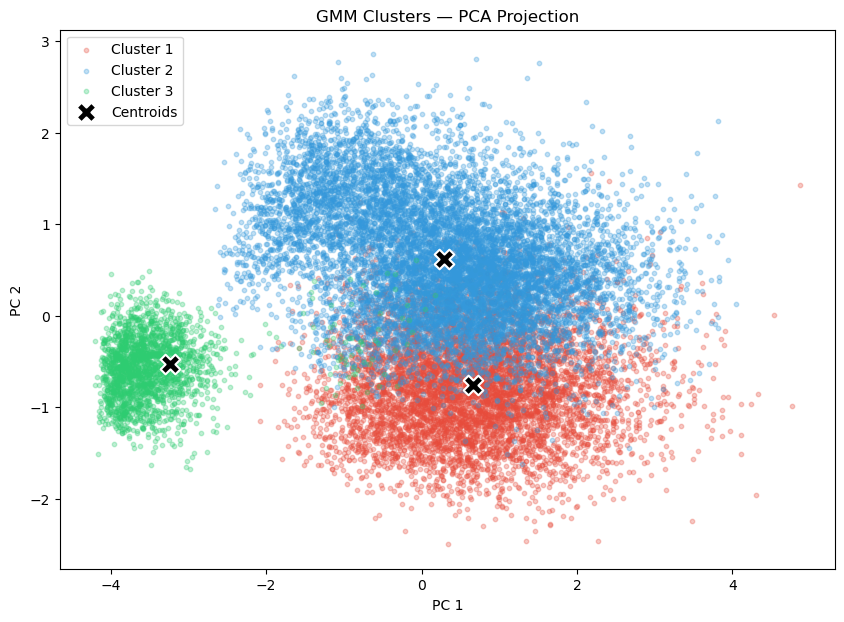

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_soccer.to_numpy())
mu_pca = pca.transform(mu)

plt.figure(figsize=(10, 7))
for k in range(K):
    mask = cluster_labels == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[k], alpha=0.3, s=10, label=f'Cluster {k+1}')
plt.scatter(mu_pca[:, 0], mu_pca[:, 1],
            c='black', marker='X', s=200, edgecolors='white', linewidths=1.5,
            label='Centroids', zorder=5)
plt.title('GMM Clusters — PCA Projection')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.show()

### 2. Pair Plot (selected features colored by cluster)

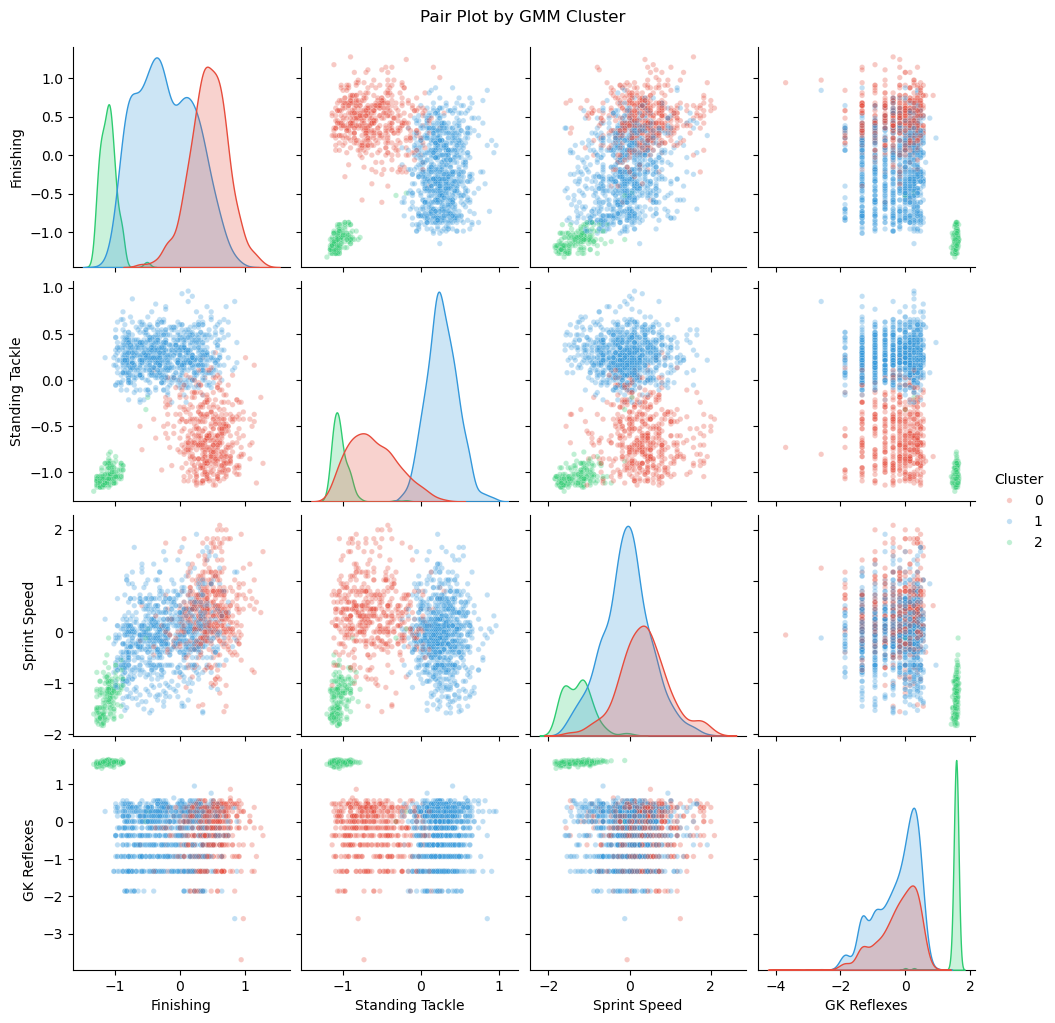

In [34]:
# Pick 4 representative features to keep the plot readable
pair_features = ['Finishing', 'Standing Tackle', 'Sprint Speed', 'GK Reflexes']

df_pair = df_clustered[pair_features + ['Cluster']].sample(1500, random_state=42)
df_pair['Cluster'] = df_pair['Cluster'].astype(str)

sns.pairplot(df_pair, hue='Cluster', diag_kind='kde',
             palette={'0': '#e74c3c', '1': '#3498db', '2': '#2ecc71'},
             plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Pair Plot by GMM Cluster', y=1.02)
plt.show()

### 3. Box Plots per Feature by Cluster

C:\Users\seboc\AppData\Local\Temp\ipykernel_28364\2545172365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clustered, x='Cluster', y=feat, ax=axes[i],
C:\Users\seboc\AppData\Local\Temp\ipykernel_28364\2545172365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clustered, x='Cluster', y=feat, ax=axes[i],
C:\Users\seboc\AppData\Local\Temp\ipykernel_28364\2545172365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clustered, x='Cluster', y=feat, ax=axes[i],
C:\Users\seboc\AppData\Local\Temp\ipykernel_28364\25

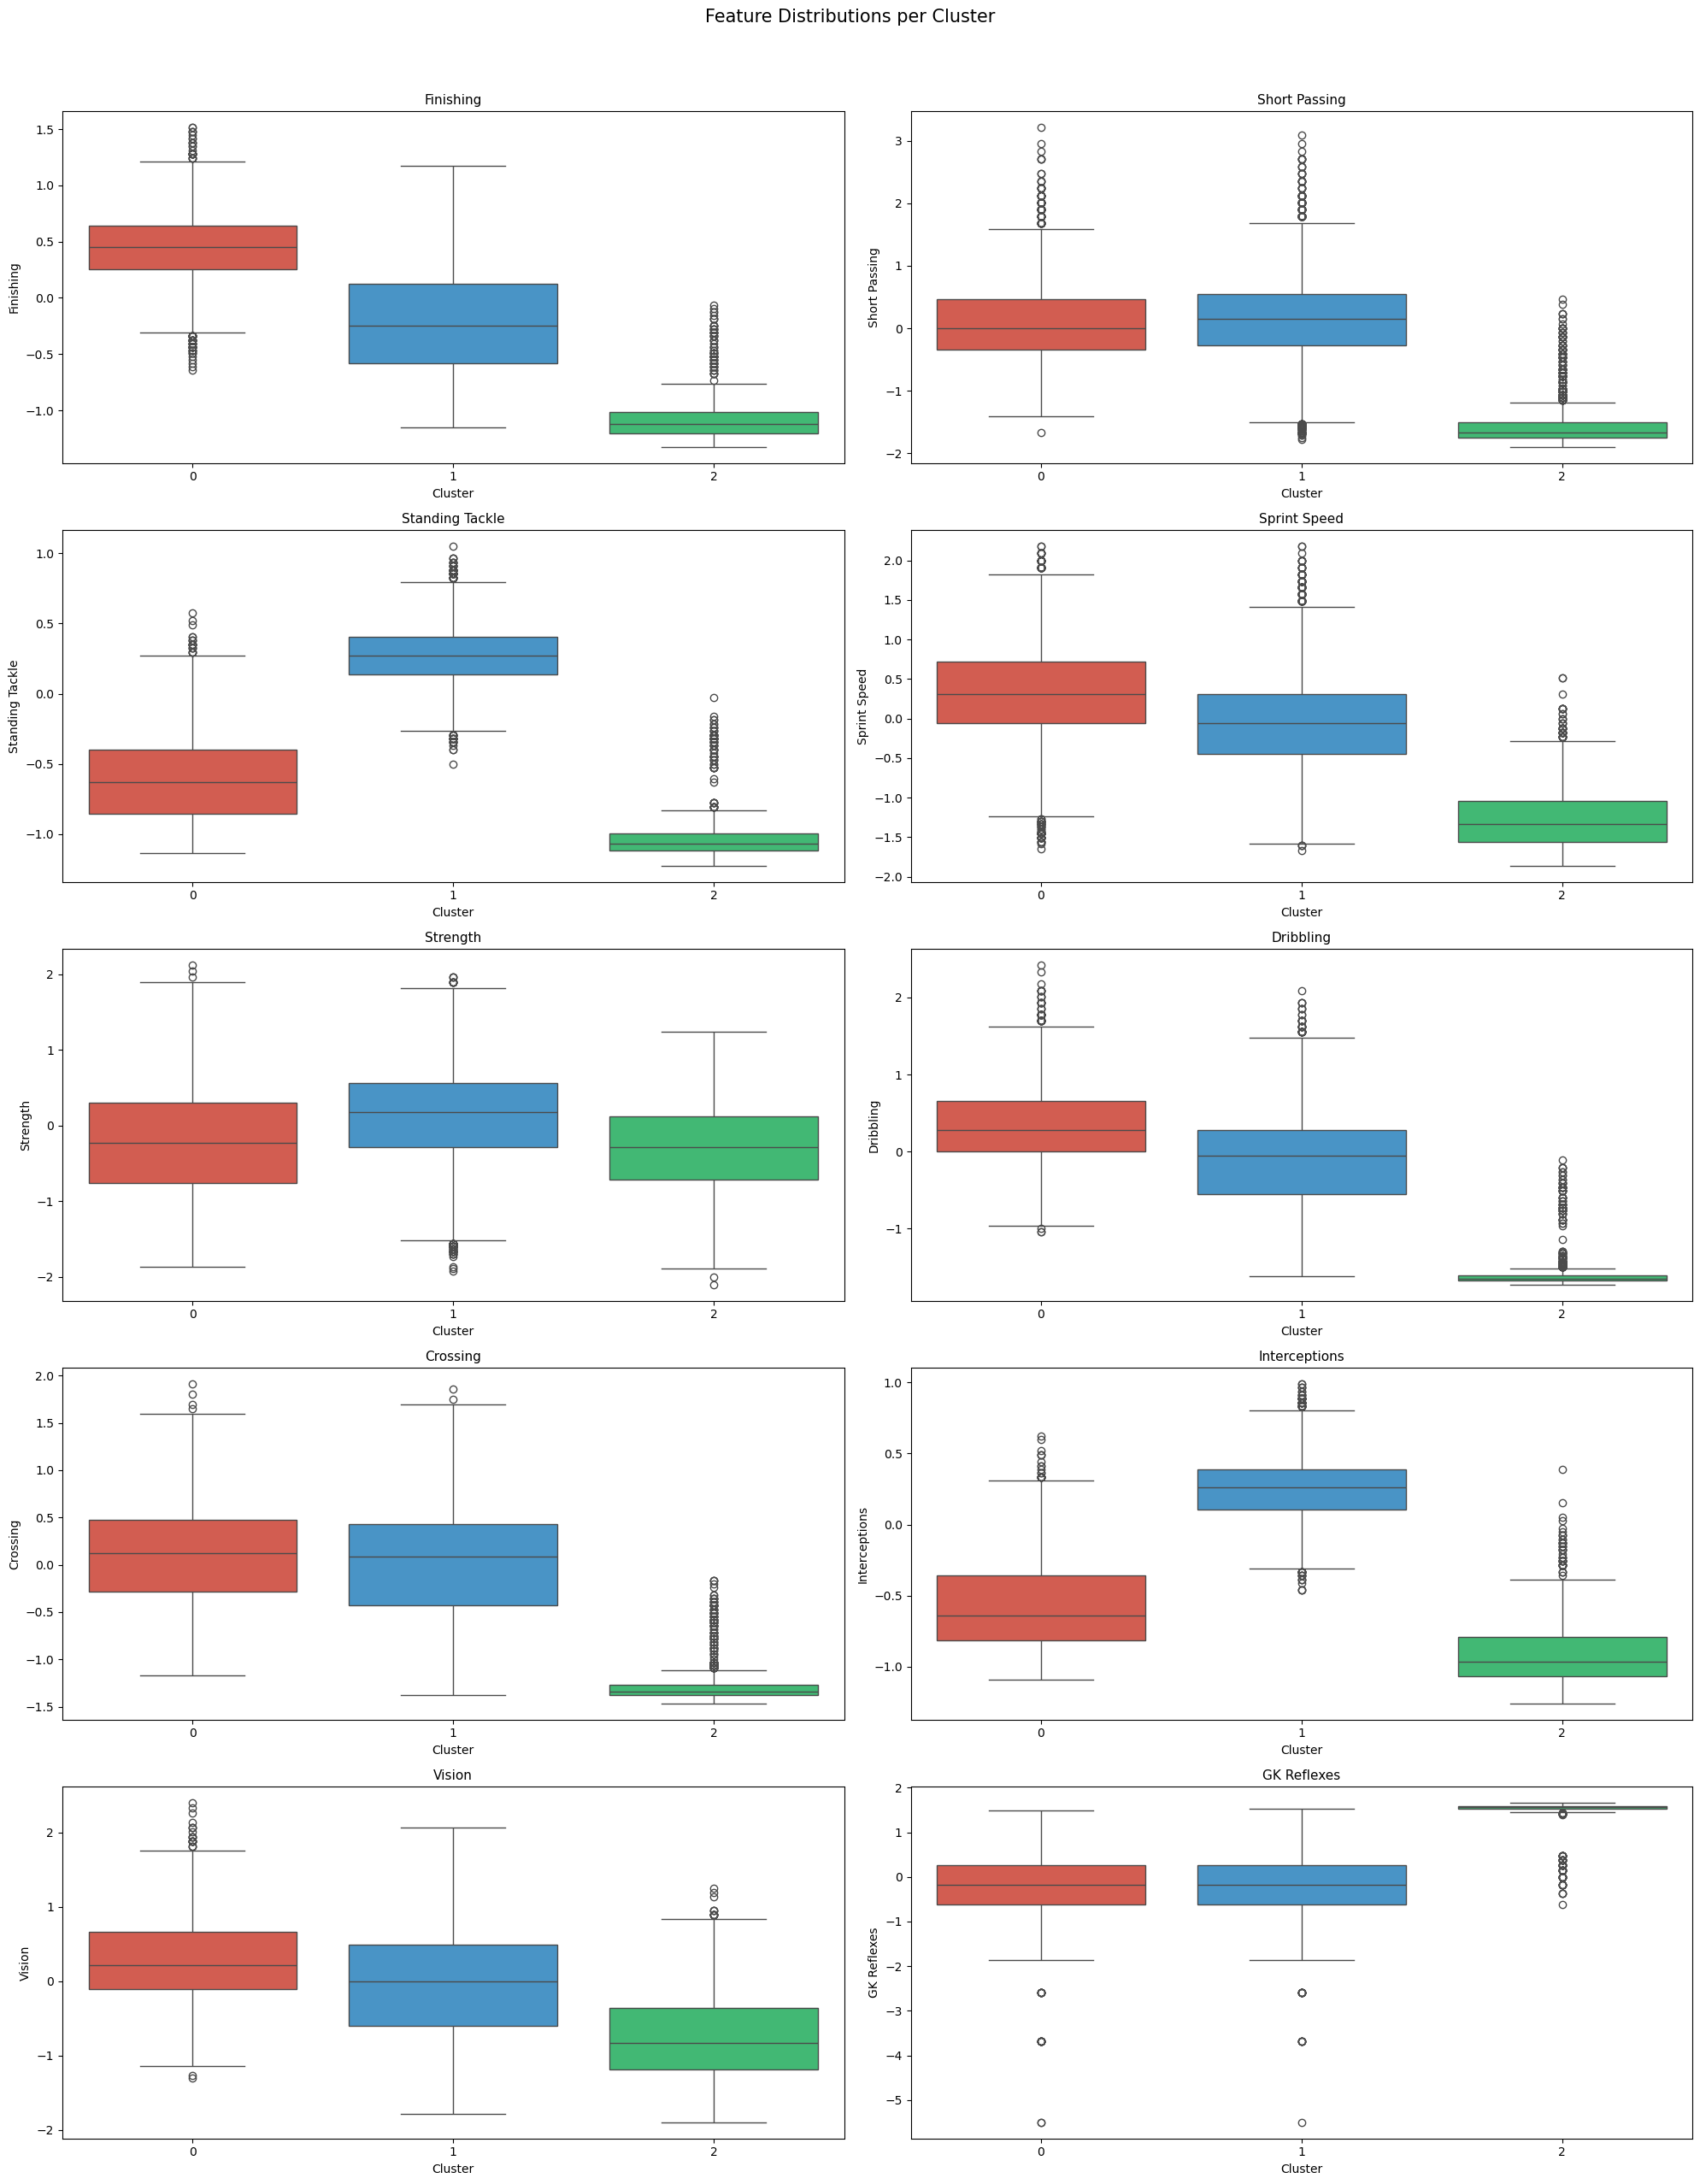

In [55]:
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.flatten()

for i, feat in enumerate(features_for_clustering):
    sns.boxplot(data=df_clustered, x='Cluster', y=feat, ax=axes[i],
                palette=colors[:K])
    axes[i].set_title(feat, fontsize=11)

plt.suptitle('Feature Distributions per Cluster', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Note: Here we are noticing that the cluster 1 tend to have in general a better attributes for attack, the cluster 3 

### 6. Rand Index — Comparing GMM Clusters vs. Position-Based Ground Truth

Since our dataset contains player skill attributes, a natural ground truth is the **player's role** derived from `Best Position`. We map all positions into 3 broad categories to match **K=3**:

| Group | Positions |
|:------|:----------|
| **Attacker** | ST, CF, LW, RW, CAM |
| **Midfielder / Defender** | CM, CDM, CB, LB, RB, LM, RM, LWB, RWB |
| **Goalkeeper** | GK |

In [56]:
from sklearn.metrics import rand_score, adjusted_rand_score

In [57]:
# --- 1. Load original dataset to get "Best Position" as ground truth ---
df_original = pd.read_excel('FIFA_Complete_DATASET.xlsx', sheet_name='Fifa')
df_original.head()

,LongName,Nationality,Positions,Name,Age,Overall Rating,Potential,ID,Weight,foot,...,Physicality,Hits,Team,Start Year,End Year,Height,Date,Year,Month,Day
0,Lionel Messi,Argentina,RW ST CF,L. Messi,33,93,93,158023,72.121128,Left,...,65,372,FC Barcelona,2004.0,2021.0,159.40,2004-07-01,2004,7,1
1,C. Ronaldo dos Santos Aveiro,Portugal,ST LW,Cristiano Ronaldo,35,92,92,20801,83.007336,Right,...,77,344,Juventus,2018.0,2022.0,184.88,2018-07-10,2018,7,10
2,Jan Oblak,Slovenia,GK,J. Oblak,27,91,93,200389,87.089664,Right,...,90,86,Atlético Madrid,2014.0,2023.0,184.88,2014-07-16,2014,7,16
3,Kevin De Bruyne,Belgium,CAM CM,K. De Bruyne,29,91,91,192985,69.853168,Right,...,78,163,Manchester City,2015.0,2023.0,163.40,2015-08-30,2015,8,30
4,Neymar da Silva Santos Jr.,Brazil,LW CAM,Neymar Jr,28,91,91,190871,68.038800,Right,...,59,273,Germain,2017.0,2022.0,161.40,2017-08-03,2017,8,3


In [59]:
df_original["Best Position"].value_counts()

Best Position
CB     3656
ST     2661
CAM    2289
GK     2057
RM     1600
CDM    1436
LB     1079
RB     1072
CM     1040
LM      868
RW      298
RWB     274
LWB     259
LW      185
CF       78
Name: count, dtype: int64

In [60]:
# --- 2. Map positions to 3 broad role categories (matching K=3) ---
position_map = {
    # Attackers
    'ST': 0, 'CF': 0, 'LW': 0, 'RW': 0, 'CAM': 0,
    # Midfielders / Defenders
    'CM': 1, 'CDM': 1, 'CB': 1, 'LB': 1, 'RB': 1,
    'LM': 1, 'RM': 1, 'LWB': 1, 'RWB': 1,
    # Goalkeepers
    'GK': 2
}

In [62]:
# Map positions; drop rows without a valid mapping
df_original['Role'] = df_original['Best Position'].map(position_map)
valid_mask = df_original['Role'].notna()

In [63]:
true_labels = df_original.loc[valid_mask, 'Role'].astype(int).values
pred_labels = cluster_labels[valid_mask.values]

In [64]:
true_labels

array([0, 0, 2, ..., 1, 0, 1])

Rand Index:          0.7821
Adjusted Rand Index: 0.5583

Interpretation:
  - Rand Index ranges from 0 to 1 (1 = perfect agreement)
  - Adjusted Rand Index corrects for chance (0 = random, 1 = perfect)

Contingency Table (True Role vs GMM Cluster):

GMM Cluster      0     1     2
True Role                     
Attacker      4672   809    30
Mid/Defender  1902  9345    37
Goalkeeper       0     0  2057


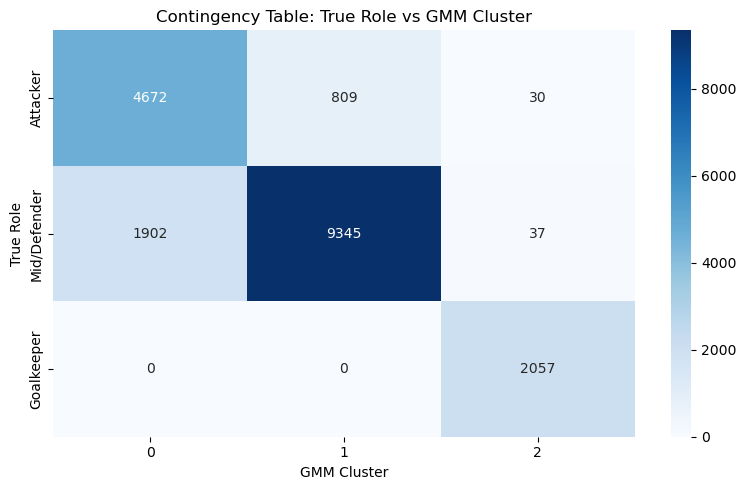

In [ ]:
# --- 3. Compute Rand Index and Adjusted Rand Index ---
ri  = rand_score(true_labels, pred_labels)
ari = adjusted_rand_score(true_labels, pred_labels)

print(f"Rand Index:          {ri:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"\nInterpretation:")
print(f"  - Rand Index ranges from 0 to 1 (1 = perfect agreement)")
print(f"  - Adjusted Rand Index corrects for chance (0 = random, 1 = perfect)")

# --- 4. Contingency table for deeper insight ---
ct = pd.crosstab(
    pd.Series(true_labels, name='True Role'),
    pd.Series(pred_labels, name='GMM Cluster'),
)
ct.index = ct.index.map({0: 'Attacker', 1: 'Mid/Defender', 2: 'Goalkeeper'})
print(f"\nContingency Table (True Role vs GMM Cluster):\n")
print(ct)

# --- 5. Visualize the contingency table ---
plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency Table: True Role vs GMM Cluster')
plt.ylabel('True Role')
plt.xlabel('GMM Cluster')
plt.tight_layout()
plt.show()